# A Multidimensional Predictive and Clustering Approach to Understanding State-Level Chronic Disease Disparities

## Team 8 - CMPE 255 Spring 2026

**Team Members:**
- Bharath Kumar A [018221268]
- Mithil Sri Sai Devisetty [019153394]
- Mani Mokshith Noonety [019100458]
- Tej Kiran Yenugunti [019104878]

---

## Project Overview

This notebook implements a comprehensive data-driven pipeline to analyze chronic disease disparities across U.S. states. We integrate eight public health datasets and apply machine learning techniques to identify predictive factors and state archetypes.

## 1. Setup and Library Installation

In [75]:
# Install gdown for Google Drive data downloads
!pip install gdown --quiet

## 2. Import Required Libraries

In [76]:
# Data manipulation
import pandas as pd
import numpy as np

# Data downloading
import gdown

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Advanced ML
from xgboost import XGBRegressor

# Statistical analysis
from scipy import stats

# Settings
import warnings
warnings.filterwarnings('ignore')

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Plotting style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## 3. Data Loading and Setup

We will load eight state-level datasets from public repositories.

In [77]:
# Create necessary directories for Google Colab
import os

# Create data and results directories if they don't exist
os.makedirs('../data', exist_ok=True)
os.makedirs('../results', exist_ok=True)

print("✓ Directories created successfully!")
print(f"  - ../data/ for datasets")
print(f"  - ../results/ for outputs")

✓ Directories created successfully!
  - ../data/ for datasets
  - ../results/ for outputs


### 3.1 Dataset 1: Chronic Disease (CDC BRFSS)

Contains state-level chronic disease metrics by year, topic, and gender.

In [78]:
# Download Chronic Disease Dataset
print("Downloading Chronic Disease dataset...")
gdown_id = "1GA_camLQGvBYLLnPa9vcNQvfZHWBWJhN"
gdown.download(id=gdown_id, output="../data/ChronicDisease.csv", quiet=False)

# Load the dataset
df_chronic = pd.read_csv("../data/ChronicDisease.csv")

print(f"\n✓ Loaded Chronic Disease dataset: {df_chronic.shape}")
print(f"Columns: {df_chronic.shape[1]}")
print(f"Rows: {df_chronic.shape[0]}")

Downloading...
From: https://drive.google.com/uc?id=1GA_camLQGvBYLLnPa9vcNQvfZHWBWJhN
To: /data/ChronicDisease.csv
100%|██████████| 88.2M/88.2M [00:02<00:00, 30.3MB/s]



✓ Loaded Chronic Disease dataset: (309215, 34)
Columns: 34
Rows: 309215


In [79]:
# Initial exploration
print("Dataset Info:")
df_chronic.info()

print("\nFirst 5 rows:")
df_chronic.head()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 309215 entries, 0 to 309214
Data columns (total 34 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   YearStart                  309215 non-null  int64  
 1   YearEnd                    309215 non-null  int64  
 2   LocationAbbr               309215 non-null  object 
 3   LocationDesc               309215 non-null  object 
 4   DataSource                 309215 non-null  object 
 5   Topic                      309215 non-null  object 
 6   Question                   309215 non-null  object 
 7   Response                   0 non-null       float64
 8   DataValueUnit              309215 non-null  object 
 9   DataValueType              309215 non-null  object 
 10  DataValue                  209196 non-null  float64
 11  DataValueAlt               209196 non-null  float64
 12  DataValueFootnoteSymbol    101716 non-null  object 
 13  DataValueFootno

,YearStart,YearEnd,LocationAbbr,LocationDesc,DataSource,Topic,Question,Response,DataValueUnit,DataValueType,DataValue,DataValueAlt,DataValueFootnoteSymbol,DataValueFootnote,LowConfidenceLimit,HighConfidenceLimit,StratificationCategory1,Stratification1,StratificationCategory2,Stratification2,StratificationCategory3,Stratification3,Geolocation,LocationID,TopicID,QuestionID,ResponseID,DataValueTypeID,StratificationCategoryID1,StratificationID1,StratificationCategoryID2,StratificationID2,StratificationCategoryID3,StratificationID3
0,2020,2020,US,United States,BRFSS,Health Status,Recent activity limitation among adults,NaN,Number,Age-adjusted Mean,2.9,2.9,NaN,NaN,2.8,2.9,Sex,Female,NaN,NaN,NaN,NaN,NaN,59,HEA,HEA04,NaN,AGEADJMEAN,SEX,SEXF,NaN,NaN,NaN,NaN
1,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,9537.0,9537.0,NaN,NaN,NaN,NaN,Sex,Male,NaN,NaN,NaN,NaN,POINT (-92.27449074299966 34.74865012400045),5,CAN,CAN07,NaN,NMBR,SEX,SEXM,NaN,NaN,NaN,NaN
2,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",NaN,Number,Number,486.0,486.0,NaN,NaN,NaN,NaN,Overall,Overall,NaN,NaN,NaN,NaN,POINT (-120.99999953799971 37.63864012300047),6,CAN,CAN03,NaN,NMBR,OVERALL,OVR,NaN,NaN,NaN,NaN
3,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",NaN,Number,Number,2880.0,2880.0,NaN,NaN,NaN,NaN,Race/Ethnicity,Hispanic,NaN,NaN,NaN,NaN,POINT (-106.13361092099967 38.843840757000464),8,CAN,CAN07,NaN,NMBR,RACE,HIS,NaN,NaN,NaN,NaN
4,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",NaN,Number,Number,519.0,519.0,NaN,NaN,NaN,NaN,Race/Ethnicity,"White, non-Hispanic",NaN,NaN,NaN,NaN,POINT (-83.62758034599966 32.83968109300048),13,CAN,CAN05,NaN,NMBR,RACE,WHT,NaN,NaN,NaN,NaN


In [80]:
# Check for missing values
print("Missing values per column:")
df_chronic.isnull().sum()

Missing values per column:


,0
YearStart,0
YearEnd,0
LocationAbbr,0
LocationDesc,0
DataSource,0
Topic,0
Question,0
Response,309215
DataValueUnit,0
DataValueType,0


### 3.2 Clean Chronic Disease Dataset

We'll clean the dataset by:
1. Removing unnecessary columns
2. Filtering relevant disease topics
3. Removing non-state entries (US aggregates, territories)
4. Handling missing values

In [81]:
# Step 1: Drop unnecessary columns
cols_to_drop = [
    "Response", "DataValueAlt", "DataValueFootnoteSymbol", "DataValueFootnote",
    "LowConfidenceLimit", "HighConfidenceLimit",
    "StratificationCategory2", "Stratification2",
    "StratificationCategory3", "Stratification3",
    "StratificationCategoryID2", "StratificationID2",
    "StratificationCategoryID3", "StratificationID3",
    "ResponseID", "Geolocation", "LocationID", "TopicID", "QuestionID", "DataValueTypeID"
]

df_chronic_clean = df_chronic.drop(columns=[c for c in cols_to_drop if c in df_chronic.columns])

print(f"✓ Dropped {len([c for c in cols_to_drop if c in df_chronic.columns])} unnecessary columns")
print(f"Remaining columns: {df_chronic_clean.shape[1]}")

✓ Dropped 20 unnecessary columns
Remaining columns: 14


In [82]:
# Step 2: Filter relevant disease topics (remove non-chronic disease topics)
topics_to_drop = [
    "Nutrition, Physical Activity, and Weight Status",
    "Health Status",
    "Social Determinants of Health",
    "Immunization",
    "Cognitive Health and Caregiving",
    "Maternal Health"
]

df_chronic_clean = df_chronic_clean[~df_chronic_clean["Topic"].isin(topics_to_drop)]

print(f"✓ Filtered to chronic disease topics only")
print(f"Remaining rows: {df_chronic_clean.shape[0]}")

✓ Filtered to chronic disease topics only
Remaining rows: 208438


In [83]:
# Step 3: Remove rows with missing DataValue
df_chronic_clean = df_chronic_clean[df_chronic_clean["DataValue"].notna()]

print(f"✓ Removed rows with missing disease values")
print(f"Remaining rows: {df_chronic_clean.shape[0]}")

✓ Removed rows with missing disease values
Remaining rows: 141488


In [84]:
# Step 4: Standardize data types and rename columns
df_chronic_clean["YearStart"] = df_chronic_clean["YearStart"].astype(int)
df_chronic_clean["YearEnd"] = df_chronic_clean["YearEnd"].astype(int)
df_chronic_clean["DataValue"] = pd.to_numeric(df_chronic_clean["DataValue"], errors="coerce")
df_chronic_clean["Year"] = df_chronic_clean["YearStart"]
df_chronic_clean = df_chronic_clean.rename(columns={"LocationDesc": "State"})

print("✓ Standardized data types and renamed columns")
print(f"\n\nData types:")
print(df_chronic_clean.dtypes)

✓ Standardized data types and renamed columns


Data types:
YearStart                      int64
YearEnd                        int64
LocationAbbr                  object
State                         object
DataSource                    object
Topic                         object
Question                      object
DataValueUnit                 object
DataValueType                 object
DataValue                    float64
StratificationCategory1       object
Stratification1               object
StratificationCategoryID1     object
StratificationID1             object
Year                           int64
dtype: object


In [85]:
# Step 5: Remove non-state entries (US aggregates, territories)
df_chronic_clean = df_chronic_clean[
    (df_chronic_clean["State"] != "United States") &
    (df_chronic_clean["State"] != "Puerto Rico")
].reset_index(drop=True)

print(f"✓ Removed non-state entries")
print(f"Final cleaned dataset shape: {df_chronic_clean.shape}")
print(f"\\nUnique states: {df_chronic_clean['State'].nunique()}")
print(f"Unique disease topics: {df_chronic_clean['Topic'].nunique()}")

✓ Removed non-state entries
Final cleaned dataset shape: (137020, 15)
\nUnique states: 53
Unique disease topics: 13


In [86]:
# Display cleaned data sample
print("Cleaned Chronic Disease Dataset Sample:")
df_chronic_clean.head(10)

Cleaned Chronic Disease Dataset Sample:


,YearStart,YearEnd,LocationAbbr,State,DataSource,Topic,Question,DataValueUnit,DataValueType,DataValue,StratificationCategory1,Stratification1,StratificationCategoryID1,StratificationID1,Year
0,2015,2019,AR,Arkansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,9537.0,Sex,Male,SEX,SEXM,2015
1,2015,2019,CA,California,US Cancer DVT,Cancer,"Cervical cancer mortality among all females, u...",Number,Number,486.0,Overall,Overall,OVERALL,OVR,2015
2,2015,2019,CO,Colorado,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,2880.0,Race/Ethnicity,Hispanic,RACE,HIS,2015
3,2015,2019,GA,Georgia,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...",Number,Number,519.0,Race/Ethnicity,"White, non-Hispanic",RACE,WHT,2015
4,2015,2019,KS,Kansas,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,8102.0,Sex,Male,SEX,SEXM,2015
5,2015,2019,ME,Maine,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,9238.0,Overall,Overall,OVERALL,OVR,2015
6,2015,2019,NJ,New Jersey,US Cancer DVT,Cancer,"Invasive cancer (all sites combined), incidence",Number,Number,5587.0,Race/Ethnicity,Hispanic,RACE,HIS,2015
7,2015,2019,NY,New York,US Cancer DVT,Cancer,"Breast cancer mortality among all females, und...",Number,Number,2547.0,Sex,Female,SEX,SEXF,2015
8,2015,2019,OR,Oregon,US Cancer DVT,Cancer,"Breast cancer mortality among all females, und...",Number,Number,548.0,Overall,Overall,OVERALL,OVR,2015
9,2015,2019,SD,South Dakota,US Cancer DVT,Cancer,"Prostate cancer mortality among all males, und...","per 100,000",Crude Rate,20.2,Overall,Overall,OVERALL,OVR,2015


## 4. Healthcare Expenditure Data (2015-2020)

Loading state-level healthcare spending data to analyze resource allocation patterns.

In [87]:
# Download Healthcare Expenditure Dataset
print("Downloading Healthcare Expenditure dataset...")
gdown.download(id="1fcDO9LkieCtt5C1jr5ejdHe9_MsFR0pU", output="../data/Healthexpense.csv", quiet=False)

# Load dataset
df_expenditure = pd.read_csv("../data/Healthexpense.csv")

print(f"\n✓ Loaded Healthcare Expenditure dataset: {df_expenditure.shape}")
print(f"Years covered: 2015-2020")
df_expenditure.head()

Downloading...
From: https://drive.google.com/uc?id=1fcDO9LkieCtt5C1jr5ejdHe9_MsFR0pU
To: /data/Healthexpense.csv
100%|██████████| 138k/138k [00:00<00:00, 77.2MB/s]


✓ Loaded Healthcare Expenditure dataset: (600, 37)
Years covered: 2015-2020


,Code,Item,Group,Region_Number,Region_Name,State_Name,Y1991,Y1992,Y1993,Y1994,Y1995,Y1996,Y1997,Y1998,Y1999,Y2000,Y2001,Y2002,Y2003,Y2004,Y2005,Y2006,Y2007,Y2008,Y2009,Y2010,Y2011,Y2012,Y2013,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Average_Annual_Percent_Growth
0,1,Personal Health Care (Millions of Dollars),United States,0,United States,NaN,672711,728437,775720,817952,866811,915029,966064,1019653,1079208,1157014,1257063,1366087,1476505,1582999,1694411,1806963,1922157,2007967,2106233,2181261,2254675,2346962,2405667,2527325,2674089,2795322,2905160,3021796,3175230,3357832,5.7
1,1,Personal Health Care (Millions of Dollars),Region,1,New England,NaN,40981,43705,46452,48478,52029,54760,58092,62148,65048,69388,75434,82193,88618,95122,101227,108472,115485,121097,127743,130858,134084,138405,141505,146939,154957,161532,166153,172783,180021,188974,5.4
2,1,Personal Health Care (Millions of Dollars),Region,2,Mideast,NaN,135126,146315,155597,164420,173157,180512,189043,197882,210031,222895,240500,259892,281047,299190,317484,335952,354565,367107,385989,400739,414205,424773,437249,458170,481439,505965,528624,551923,578722,613211,5.4
3,1,Personal Health Care (Millions of Dollars),Region,3,Great Lakes,NaN,112461,121265,129054,135860,143812,151683,158844,165707,174828,187589,203508,219640,235677,251683,267060,284375,300839,309471,324367,335104,343926,357464,364541,380858,396851,411931,424240,435750,457486,478682,5.1
4,1,Personal Health Care (Millions of Dollars),Region,4,Plains,NaN,45761,49118,52134,56024,59449,63197,66931,71895,76185,82337,89218,96967,104150,110536,117225,123940,132592,138683,144328,149731,155601,161775,165072,171981,180290,187565,192945,200391,209318,220945,5.6


In [88]:
# Check data structure
print("Expenditure dataset info:")
df_expenditure.info()

print("\nColumn names:")
print(df_expenditure.columns.tolist())

Expenditure dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 37 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Code                           600 non-null    int64  
 1   Item                           600 non-null    object 
 2   Group                          600 non-null    object 
 3   Region_Number                  600 non-null    int64  
 4   Region_Name                    600 non-null    object 
 5   State_Name                     510 non-null    object 
 6   Y1991                          600 non-null    int64  
 7   Y1992                          600 non-null    int64  
 8   Y1993                          600 non-null    int64  
 9   Y1994                          600 non-null    int64  
 10  Y1995                          600 non-null    int64  
 11  Y1996                          600 non-null    int64  
 12  Y1997                   

In [89]:
# Calculate total expenditure 2015-2020
# Note: Need to identify year columns and aggregate
print("TODO: Aggregate spending across 2015-2020")
print("TODO: Handle missing values")
print("TODO: Standardize state names for merging")

# Initial aggregation attempt
if 'Y2015' in df_expenditure.columns:
    year_cols = ['Y2015', 'Y2016', 'Y2017', 'Y2018', 'Y2019', 'Y2020']
    df_expenditure['Total_Expense_2015_2020'] = df_expenditure[year_cols].sum(axis=1)
    print("\n✓ Calculated total expenditure")
else:
    print("\n⚠ Need to identify year columns correctly")

TODO: Aggregate spending across 2015-2020
TODO: Handle missing values
TODO: Standardize state names for merging

✓ Calculated total expenditure


## 5. Healthcare Workforce Data

Loading physicians and hospitals datasets to analyze healthcare capacity.

In [90]:
# Download Physicians Dataset
print("Downloading Physicians dataset...")
gdown.download(id="1giEZL5n4DP3G4WaVt-v7_rqdKO6m2dNa", output="../data/Physicians.csv", quiet=False)

df_physicians = pd.read_csv("../data/Physicians.csv")

print(f"\n✓ Loaded Physicians dataset: {df_physicians.shape}")
df_physicians.head()

Downloading...
From: https://drive.google.com/uc?id=1giEZL5n4DP3G4WaVt-v7_rqdKO6m2dNa
To: /data/Physicians.csv
100%|██████████| 1.37k/1.37k [00:00<00:00, 5.31MB/s]


✓ Loaded Physicians dataset: (51, 4)


,State,PrimaryCare,Specialists,TotalPhysicians
0,Alabama,6534,6243,12777
1,Alaska,1273,1111,2384
2,Arizona,10159,11289,21448
3,Arkansas,4230,3977,8207
4,California,63465,65064,128529


In [91]:
# Download Hospitals Dataset
print("Downloading Hospitals dataset...")
gdown.download(id="1X0TXbHc-5y1_W5mPSZM7SXgSVin1dSo9", output="../data/hospitals.csv", quiet=False)

df_hospitals = pd.read_csv("../data/hospitals.csv")

print(f"\n✓ Loaded Hospitals dataset: {df_hospitals.shape}")
df_hospitals.head()

Downloading...
From: https://drive.google.com/uc?id=1X0TXbHc-5y1_W5mPSZM7SXgSVin1dSo9
To: /data/hospitals.csv
100%|██████████| 705/705 [00:00<00:00, 2.94MB/s]


✓ Loaded Hospitals dataset: (52, 2)


,Location,TotalHospitals
0,Alabama,101
1,Alaska,20
2,Arizona,81
3,Arkansas,90
4,California,353


In [92]:
# Check data structure for both datasets
print("Physicians columns:", df_physicians.columns.tolist())
print("\nHospitals columns:", df_hospitals.columns.tolist())

# TODO: Calculate per 100k metrics once we have population data
print("\n⚠ Note: Will calculate Physicians_Per100k and Hospitals_Per100k after loading population data")

Physicians columns: ['State', 'PrimaryCare', 'Specialists', 'TotalPhysicians']

Hospitals columns: ['Location', 'TotalHospitals']

⚠ Note: Will calculate Physicians_Per100k and Hospitals_Per100k after loading population data


## 6. Environmental and Behavioral Risk Factors

Loading physical inactivity and PM2.5 pollution datasets.

In [93]:
# Download Physical Inactivity Dataset
print("Downloading Physical Inactivity dataset...")
gdown.download(id="17CymbIRG6qrmcL-ZMYDqWTOB0c8PtaT4", output="../data/PhysicalActivity.csv", quiet=False)

df_inactivity = pd.read_csv("../data/PhysicalActivity.csv")

print(f"\n✓ Loaded Physical Inactivity dataset: {df_inactivity.shape}")
df_inactivity.head()

Downloading...
From: https://drive.google.com/uc?id=17CymbIRG6qrmcL-ZMYDqWTOB0c8PtaT4
To: /data/PhysicalActivity.csv
100%|██████████| 1.66k/1.66k [00:00<00:00, 5.06MB/s]


✓ Loaded Physical Inactivity dataset: (53, 3)


,State,Prevalence,95% Confidence Interval
0,Alabama,30.7,"(29.9, 31.5)"
1,Alaska,20.8,"(19.7, 22)"
2,Arizona,23.3,"(22.7, 24)"
3,Arkansas,31.1,"(30.1, 32.1)"
4,California,21.2,"(20.5, 21.8)"


In [94]:
# Download PM2.5 Pollution Dataset
print("Downloading PM2.5 Pollution dataset...")
gdown.download(id="1C1GpHWB8wjriN13Jw5O7NM8nqQOVN1AU", output="../data/pollution.csv", quiet=False)

df_pollution = pd.read_csv("../data/pollution.csv")

print(f"\n✓ Loaded PM2.5 Pollution dataset: {df_pollution.shape}")
df_pollution.head()

Downloading...
From: https://drive.google.com/uc?id=1C1GpHWB8wjriN13Jw5O7NM8nqQOVN1AU
To: /data/pollution.csv
100%|██████████| 1.04k/1.04k [00:00<00:00, 4.60MB/s]


✓ Loaded PM2.5 Pollution dataset: (53, 3)


,State,FIPS,PM25
0,United States,0,7.3
1,California,6000,12.6
2,Oregon,41000,12.1
3,Washington,53000,10.3
4,Oklahoma,40000,8.9


In [95]:
# Download Population Dataset (needed for per-capita calculations)
print("Downloading Population dataset...")
gdown.download(id="1SiHB7Td9piKz3QpTQnDuEWCU7K6U-r6i", output="../data/Population.csv", quiet=False)

df_population = pd.read_csv("../data/Population.csv")

print(f"\n✓ Loaded Population dataset: {df_population.shape}")
df_population.head()

Downloading...
From: https://drive.google.com/uc?id=1SiHB7Td9piKz3QpTQnDuEWCU7K6U-r6i
To: /data/Population.csv
100%|██████████| 893/893 [00:00<00:00, 2.33MB/s]


✓ Loaded Population dataset: (50, 2)


,State,Population
0,Alabama,5024279
1,Alaska,733391
2,Arizona,7151502
3,Arkansas,3011524
4,California,39538223


## 7. Summary and Next Steps

**Data Loading Complete:**
- ✅ Chronic Disease Dataset (cleaned)
- ✅ Healthcare Expenditure Dataset
- ✅ Physicians Dataset  
- ✅ Hospitals Dataset
- ✅ Physical Inactivity Dataset
- ✅ PM2.5 Pollution Dataset
- ✅ Population Dataset

**Next Steps:**
- Merge all datasets into master dataframe
- Engineer per-capita and per-100k features
- Conduct comprehensive EDA
- Build predictive ML models
- Perform clustering analysis
- Answer research questions

## 8. Per Capita Healthcare Expenditure Dataset

Loading per capita spending data for additional spending analysis.

---

**Next Steps:**
- Load remaining 7 datasets
- Clean and preprocess each dataset
- Create master dataframe
- Perform EDA
- Build ML models

In [96]:
# Download Per Capita Expenditure Dataset
print("Downloading Per Capita Expenditure dataset...")
gdown.download(id="1duB3gZoyUW7NcpJ39r2vXiMAB7r6XjSy", output="../data/US_PER_CAPITA20.CSV", quiet=False)

df_percapita = pd.read_csv("../data/US_PER_CAPITA20.CSV")

print(f"\n✓ Loaded Per Capita Expenditure dataset: {df_percapita.shape}")
df_percapita.head()

Downloading...
From: https://drive.google.com/uc?id=1duB3gZoyUW7NcpJ39r2vXiMAB7r6XjSy
To: /data/US_PER_CAPITA20.CSV
100%|██████████| 115k/115k [00:00<00:00, 96.4MB/s]


✓ Loaded Per Capita Expenditure dataset: (600, 37)


,Code,Item,Group,Region_Number,Region_Name,State_Name,Y1991,Y1992,Y1993,Y1994,Y1995,Y1996,Y1997,Y1998,Y1999,Y2000,Y2001,Y2002,Y2003,Y2004,Y2005,Y2006,Y2007,Y2008,Y2009,Y2010,Y2011,Y2012,Y2013,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Average_Annual_Percent_Growth
0,1,Personal Health Care ($),United States,0,United States,NaN,2659,2840,2984,3109,3255,3397,3543,3696,3868,4101,4411,4750,5090,5406,5734,6056,6381,6603,6866,7052,7236,7477,7611,7938,8337,8652,8936,9246,9671,10191,4.7
1,1,Personal Health Care ($),Region,1,New England,NaN,3093,3293,3484,3619,3862,4040,4258,4525,4701,4974,5372,5820,6248,6696,7120,7614,8088,8445,8869,9043,9226,9484,9660,9990,10516,10940,11221,11643,12123,12728,5.0
2,1,Personal Health Care ($),Region,2,Mideast,NaN,3066,3296,3480,3656,3832,3977,4148,4318,4555,4805,5159,5548,5975,6344,6721,7097,7469,7699,8051,8313,8550,8735,8967,9375,9840,10338,10797,11273,11836,12577,5.0
3,1,Personal Health Care ($),Region,3,Great Lakes,NaN,2646,2827,2982,3117,3274,3429,3570,3705,3888,4149,4482,4822,5156,5490,5812,6172,6513,6688,6997,7216,7393,7672,7806,8143,8481,8797,9050,9291,9754,10221,4.8
4,1,Personal Health Care ($),Region,4,Plains,NaN,2565,2725,2863,3048,3205,3379,3550,3786,3982,4272,4605,4981,5322,5614,5920,6210,6595,6849,7077,7291,7537,7794,7907,8192,8547,8852,9066,9381,9765,10285,4.9


## 9. Data Cleaning - Healthcare Expenditure Dataset

**Lead: Mithil Sri Sai Devisetty**

Cleaning and processing healthcare spending data to prepare for master dataframe integration.

In [97]:
# Clean expenditure dataset - standardize state names and calculate totals
print("Cleaning Healthcare Expenditure dataset...")

# Check column names
print(f"Columns: {df_expenditure.columns.tolist()}")

# If State column exists, standardize it
if 'State' in df_expenditure.columns:
    df_expenditure['State'] = df_expenditure['State'].str.strip()
    print(f"✓ Standardized state names")
else:
    print("⚠ Need to identify state column name")

# Calculate total expenditure across years if not already done
year_cols = ['Y2015', 'Y2016', 'Y2017', 'Y2018', 'Y2019', 'Y2020']
if all(col in df_expenditure.columns for col in year_cols):
    df_expenditure['Total_Expense_2015_2020'] = df_expenditure[year_cols].sum(axis=1)
    print(f"✓ Calculated Total_Expense_2015_2020")
    print(f"Mean total expenditure: ${df_expenditure['Total_Expense_2015_2020'].mean():,.0f}")
else:
    print("⚠ Year columns not found, checking column structure...")

print(f"\nExpenditure dataset shape: {df_expenditure.shape}")
df_expenditure.head()

Cleaning Healthcare Expenditure dataset...
Columns: ['Code', 'Item', 'Group', 'Region_Number', 'Region_Name', 'State_Name', 'Y1991', 'Y1992', 'Y1993', 'Y1994', 'Y1995', 'Y1996', 'Y1997', 'Y1998', 'Y1999', 'Y2000', 'Y2001', 'Y2002', 'Y2003', 'Y2004', 'Y2005', 'Y2006', 'Y2007', 'Y2008', 'Y2009', 'Y2010', 'Y2011', 'Y2012', 'Y2013', 'Y2014', 'Y2015', 'Y2016', 'Y2017', 'Y2018', 'Y2019', 'Y2020', 'Average_Annual_Percent_Growth', 'Total_Expense_2015_2020']
⚠ Need to identify state column name
✓ Calculated Total_Expense_2015_2020
Mean total expenditure: $179,294

Expenditure dataset shape: (600, 38)


,Code,Item,Group,Region_Number,Region_Name,State_Name,Y1991,Y1992,Y1993,Y1994,Y1995,Y1996,Y1997,Y1998,Y1999,Y2000,Y2001,Y2002,Y2003,Y2004,Y2005,Y2006,Y2007,Y2008,Y2009,Y2010,Y2011,Y2012,Y2013,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Average_Annual_Percent_Growth,Total_Expense_2015_2020
0,1,Personal Health Care (Millions of Dollars),United States,0,United States,NaN,672711,728437,775720,817952,866811,915029,966064,1019653,1079208,1157014,1257063,1366087,1476505,1582999,1694411,1806963,1922157,2007967,2106233,2181261,2254675,2346962,2405667,2527325,2674089,2795322,2905160,3021796,3175230,3357832,5.7,17929429
1,1,Personal Health Care (Millions of Dollars),Region,1,New England,NaN,40981,43705,46452,48478,52029,54760,58092,62148,65048,69388,75434,82193,88618,95122,101227,108472,115485,121097,127743,130858,134084,138405,141505,146939,154957,161532,166153,172783,180021,188974,5.4,1024420
2,1,Personal Health Care (Millions of Dollars),Region,2,Mideast,NaN,135126,146315,155597,164420,173157,180512,189043,197882,210031,222895,240500,259892,281047,299190,317484,335952,354565,367107,385989,400739,414205,424773,437249,458170,481439,505965,528624,551923,578722,613211,5.4,3259884
3,1,Personal Health Care (Millions of Dollars),Region,3,Great Lakes,NaN,112461,121265,129054,135860,143812,151683,158844,165707,174828,187589,203508,219640,235677,251683,267060,284375,300839,309471,324367,335104,343926,357464,364541,380858,396851,411931,424240,435750,457486,478682,5.1,2604940
4,1,Personal Health Care (Millions of Dollars),Region,4,Plains,NaN,45761,49118,52134,56024,59449,63197,66931,71895,76185,82337,89218,96967,104150,110536,117225,123940,132592,138683,144328,149731,155601,161775,165072,171981,180290,187565,192945,200391,209318,220945,5.6,1191454


In [98]:
# Clean Physicians dataset
print("\nCleaning Physicians dataset...")

# Standardize state names
if 'State' in df_physicians.columns:
    df_physicians['State'] = df_physicians['State'].str.strip()
    print(f"✓ Standardized state names")

# Check for duplicates
duplicates = df_physicians.duplicated(subset=['State']).sum()
print(f"Duplicate states: {duplicates}")

if duplicates > 0:
    df_physicians = df_physicians.drop_duplicates(subset=['State'], keep='first')
    print(f"✓ Removed {duplicates} duplicate states")

print(f"Physicians dataset shape: {df_physicians.shape}")
print(f"Unique states: {df_physicians['State'].nunique()}")
df_physicians.head()


Cleaning Physicians dataset...
✓ Standardized state names
Duplicate states: 0
Physicians dataset shape: (51, 4)
Unique states: 51


,State,PrimaryCare,Specialists,TotalPhysicians
0,Alabama,6534,6243,12777
1,Alaska,1273,1111,2384
2,Arizona,10159,11289,21448
3,Arkansas,4230,3977,8207
4,California,63465,65064,128529


In [99]:
# Clean Hospitals dataset
print("\nCleaning Hospitals dataset...")

# Standardize state names
if 'State' in df_hospitals.columns:
    df_hospitals['State'] = df_hospitals['State'].str.strip()
    print(f"✓ Standardized state names")

# Check for duplicates
duplicates_hosp = df_hospitals.duplicated().sum()
print(f"Duplicate states: {duplicates_hosp}")

if duplicates_hosp > 0:
    df_hospitals = df_hospitals.drop_duplicates(subset=['State'], keep='first')
    print(f"✓ Removed {duplicates_hosp} duplicate states")

print(f"Hospitals dataset shape: {df_hospitals.shape}")
print(f"Columns in df_hospitals: {df_hospitals.columns.tolist()}")
df_hospitals.head()


Cleaning Hospitals dataset...
Duplicate states: 0
Hospitals dataset shape: (52, 2)
Columns in df_hospitals: ['Location', 'TotalHospitals']


,Location,TotalHospitals
0,Alabama,101
1,Alaska,20
2,Arizona,81
3,Arkansas,90
4,California,353


In [100]:
# Clean Population dataset
print("\nCleaning Population dataset...")

# Standardize state names
if 'State' in df_population.columns:
    df_population['State'] = df_population['State'].str.strip()
elif 'NAME' in df_population.columns:
    df_population = df_population.rename(columns={'NAME': 'State'})
    df_population['State'] = df_population['State'].str.strip()

print(f"✓ Standardized state names")
print(f"Population dataset shape: {df_population.shape}")
print(f"Unique states: {df_population['State'].nunique()}")
df_population.head()


Cleaning Population dataset...
✓ Standardized state names
Population dataset shape: (50, 2)
Unique states: 50


,State,Population
0,Alabama,5024279
1,Alaska,733391
2,Arizona,7151502
3,Arkansas,3011524
4,California,39538223


In [101]:
# Clean Physical Inactivity dataset
print("\nCleaning Physical Inactivity dataset...")

# Select relevant columns
if 'LocationDesc' in df_inactivity.columns:
    df_inactivity = df_inactivity.rename(columns={'LocationDesc': 'State'})

df_inactivity['State'] = df_inactivity['State'].str.strip()

# Keep only overall stratification and remove US/territories
df_inactivity_clean = df_inactivity[
    (df_inactivity['State'] != 'United States') &
    (df_inactivity['State'] != 'Puerto Rico')
].copy()

print(f"✓ Cleaned Physical Inactivity dataset")
print(f"Shape: {df_inactivity_clean.shape}")
df_inactivity_clean.head()


Cleaning Physical Inactivity dataset...
✓ Cleaned Physical Inactivity dataset
Shape: (52, 3)


,State,Prevalence,95% Confidence Interval
0,Alabama,30.7,"(29.9, 31.5)"
1,Alaska,20.8,"(19.7, 22)"
2,Arizona,23.3,"(22.7, 24)"
3,Arkansas,31.1,"(30.1, 32.1)"
4,California,21.2,"(20.5, 21.8)"


In [102]:
# Clean PM2.5 Pollution dataset
print("\nCleaning PM2.5 Pollution dataset...")

# Standardize state names
if 'State' in df_pollution.columns:
    df_pollution['State'] = df_pollution['State'].str.strip()
elif 'LocationDesc' in df_pollution.columns:
    df_pollution = df_pollution.rename(columns={'LocationDesc': 'State'})
    df_pollution['State'] = df_pollution['State'].str.strip()

# Remove US/territories
df_pollution_clean = df_pollution[
    (df_pollution['State'] != 'United States') &
    (df_pollution['State'] != 'Puerto Rico')
].copy()

print(f"✓ Cleaned PM2.5 Pollution dataset")
print(f"Shape: {df_pollution_clean.shape}")
df_pollution_clean.head()


Cleaning PM2.5 Pollution dataset...
✓ Cleaned PM2.5 Pollution dataset
Shape: (51, 3)


,State,FIPS,PM25
1,California,6000,12.6
2,Oregon,41000,12.1
3,Washington,53000,10.3
4,Oklahoma,40000,8.9
5,Georgia,13000,8.8


In [103]:
# Clean Per Capita Expenditure dataset
print("\nCleaning Per Capita Expenditure dataset...")

# Standardize state names
if 'State' in df_percapita.columns:
    df_percapita['State'] = df_percapita['State'].str.strip()

# Calculate total per capita spending 2015-2020 if year columns exist
year_cols_pc = ['Y2015', 'Y2016', 'Y2017', 'Y2018', 'Y2019', 'Y2020']
if all(col in df_percapita.columns for col in year_cols_pc):
    df_percapita['Total_PerCapita_2015_2020'] = df_percapita[year_cols_pc].sum(axis=1)
    print(f"✓ Calculated Total_PerCapita_2015_2020")

print(f"Per Capita dataset shape: {df_percapita.shape}")
df_percapita.head()


Cleaning Per Capita Expenditure dataset...
✓ Calculated Total_PerCapita_2015_2020
Per Capita dataset shape: (600, 38)


,Code,Item,Group,Region_Number,Region_Name,State_Name,Y1991,Y1992,Y1993,Y1994,Y1995,Y1996,Y1997,Y1998,Y1999,Y2000,Y2001,Y2002,Y2003,Y2004,Y2005,Y2006,Y2007,Y2008,Y2009,Y2010,Y2011,Y2012,Y2013,Y2014,Y2015,Y2016,Y2017,Y2018,Y2019,Y2020,Average_Annual_Percent_Growth,Total_PerCapita_2015_2020
0,1,Personal Health Care ($),United States,0,United States,NaN,2659,2840,2984,3109,3255,3397,3543,3696,3868,4101,4411,4750,5090,5406,5734,6056,6381,6603,6866,7052,7236,7477,7611,7938,8337,8652,8936,9246,9671,10191,4.7,55033
1,1,Personal Health Care ($),Region,1,New England,NaN,3093,3293,3484,3619,3862,4040,4258,4525,4701,4974,5372,5820,6248,6696,7120,7614,8088,8445,8869,9043,9226,9484,9660,9990,10516,10940,11221,11643,12123,12728,5.0,69171
2,1,Personal Health Care ($),Region,2,Mideast,NaN,3066,3296,3480,3656,3832,3977,4148,4318,4555,4805,5159,5548,5975,6344,6721,7097,7469,7699,8051,8313,8550,8735,8967,9375,9840,10338,10797,11273,11836,12577,5.0,66661
3,1,Personal Health Care ($),Region,3,Great Lakes,NaN,2646,2827,2982,3117,3274,3429,3570,3705,3888,4149,4482,4822,5156,5490,5812,6172,6513,6688,6997,7216,7393,7672,7806,8143,8481,8797,9050,9291,9754,10221,4.8,55594
4,1,Personal Health Care ($),Region,4,Plains,NaN,2565,2725,2863,3048,3205,3379,3550,3786,3982,4272,4605,4981,5322,5614,5920,6210,6595,6849,7077,7291,7537,7794,7907,8192,8547,8852,9066,9381,9765,10285,4.9,55896


**✓ Commit 7 Complete:** All 7 datasets cleaned and standardized by Mithil.

## 10. Feature Engineering - Disease Summary Metrics

**Lead: Bharath Kumar A**

Creating aggregate disease metrics per state: Mean Disease Rate, Top Disease Topic, and Top Affected Gender.

In [104]:
# Step 1: Calculate Mean Disease Rate per state
print("Calculating Mean Disease Rate per state...")

df_disease_summary = df_chronic_clean.groupby('State')['DataValue'].mean().reset_index()
df_disease_summary = df_disease_summary.rename(columns={'DataValue': 'MeanDiseaseRate'})

print(f"✓ Created disease summary for {df_disease_summary.shape[0]} states")
print(f"Mean Disease Rate range: {df_disease_summary['MeanDiseaseRate'].min():.2f} - {df_disease_summary['MeanDiseaseRate'].max():.2f}")
df_disease_summary.head()

Calculating Mean Disease Rate per state...
✓ Created disease summary for 53 states
Mean Disease Rate range: 28.29 - 2325.41


,State,MeanDiseaseRate
0,Alabama,560.825633
1,Alaska,77.998005
2,Arizona,490.495366
3,Arkansas,372.123999
4,California,2123.737905


In [105]:
# Step 2: Identify Top Disease Topic per state
print("\nIdentifying Top Disease Topic per state...")

# Group by State and Topic, calculate mean disease value
topic_by_state = df_chronic_clean.groupby(['State', 'Topic'])['DataValue'].mean().reset_index()

# Find topic with highest mean value per state
top_topics = topic_by_state.loc[topic_by_state.groupby('State')['DataValue'].idxmax()]
top_topics = top_topics[['State', 'Topic']].rename(columns={'Topic': 'TopDiseaseTopic'})

# Merge with disease summary
df_disease_summary = df_disease_summary.merge(top_topics, on='State', how='left')

print(f"✓ Identified top disease topics")
print(f"\nMost common top disease topics:")
print(df_disease_summary['TopDiseaseTopic'].value_counts().head())
df_disease_summary.head()


Identifying Top Disease Topic per state...
✓ Identified top disease topics

Most common top disease topics:
TopDiseaseTopic
Chronic Obstructive Pulmonary Disease    35
Chronic Kidney Disease                   16
Oral Health                               1
Cancer                                    1
Name: count, dtype: int64


,State,MeanDiseaseRate,TopDiseaseTopic
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease
1,Alaska,77.998005,Chronic Kidney Disease
2,Arizona,490.495366,Chronic Kidney Disease
3,Arkansas,372.123999,Chronic Obstructive Pulmonary Disease
4,California,2123.737905,Chronic Kidney Disease


In [106]:
# Step 3: Identify Top Affected Gender per state
print("\nIdentifying Top Affected Gender per state...")

# Filter for gender stratification only
df_gender = df_chronic_clean[
    df_chronic_clean['StratificationCategory1'] == 'Sex'
].copy()

# Group by State and Gender
gender_by_state = df_gender.groupby(['State', 'Stratification1'])['DataValue'].mean().reset_index()

# Find gender with highest mean value per state
top_genders = gender_by_state.loc[gender_by_state.groupby('State')['DataValue'].idxmax()]
top_genders = top_genders[['State', 'Stratification1']].rename(columns={'Stratification1': 'TopAffectedGender'})

# Merge with disease summary
df_disease_summary = df_disease_summary.merge(top_genders, on='State', how='left')

print(f"✓ Identified top affected genders")
print(f"\nGender distribution:")
print(df_disease_summary['TopAffectedGender'].value_counts())

print(f"\n✓ Disease summary dataframe complete: {df_disease_summary.shape}")
df_disease_summary.head(10)


Identifying Top Affected Gender per state...
✓ Identified top affected genders

Gender distribution:
TopAffectedGender
Male      43
Female    10
Name: count, dtype: int64

✓ Disease summary dataframe complete: (53, 4)


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male
1,Alaska,77.998005,Chronic Kidney Disease,Male
2,Arizona,490.495366,Chronic Kidney Disease,Male
3,Arkansas,372.123999,Chronic Obstructive Pulmonary Disease,Male
4,California,2123.737905,Chronic Kidney Disease,Male
5,Colorado,346.081213,Chronic Obstructive Pulmonary Disease,Male
6,Connecticut,324.743660,Chronic Obstructive Pulmonary Disease,Female
7,Delaware,145.426762,Chronic Kidney Disease,Male
8,District of Columbia,86.935099,Chronic Kidney Disease,Female
9,Florida,2325.405095,Chronic Obstructive Pulmonary Disease,Male


**✓ Commit 8 Complete:** Disease summary features engineered by Bharath.

## 11. Master Dataframe Integration

**Lead: Mithil Sri Sai Devisetty**

Merging all datasets into a single master dataframe for comprehensive state-level analysis.

In [109]:
# Start with disease summary as base
df_master = df_disease_summary.copy()
print(f"Starting with disease summary: {df_master.shape}")

# Check expenditure columns first
print(f"Expenditure columns: {df_expenditure.columns.tolist()}")

# Fix State column name
if 'State_Name' in df_expenditure.columns:
    df_expenditure = df_expenditure.rename(columns={'State_Name': 'State'})
elif 'Location' in df_expenditure.columns:
    df_expenditure = df_expenditure.rename(columns={'Location': 'State'})
elif 'LocationDesc' in df_expenditure.columns:
    df_expenditure = df_expenditure.rename(columns={'LocationDesc': 'State'})

# Calculate Total_Expense_2015_2020 from year columns
year_cols = ['Y2015', 'Y2016', 'Y2017', 'Y2018', 'Y2019', 'Y2020']
available_years = [col for col in year_cols if col in df_expenditure.columns]

if available_years:
    # Convert to numeric and sum
    for col in available_years:
        df_expenditure[col] = pd.to_numeric(df_expenditure[col], errors='coerce')
    df_expenditure['Total_Expense_2015_2020'] = df_expenditure[available_years].sum(axis=1)
    print(f"✓ Calculated total from years: {available_years}")

# Merge healthcare expenditure
if 'Total_Expense_2015_2020' in df_expenditure.columns and 'State' in df_expenditure.columns:
    df_expense_merge = df_expenditure[['State', 'Total_Expense_2015_2020']].copy()
    df_master = df_master.merge(df_expense_merge, on='State', how='left')
    print(f"✓ Merged healthcare expenditure: {df_master.shape}")
else:
    print(f"⚠ Expenditure total column not found")

df_master.head()

Starting with disease summary: (53, 4)
Expenditure columns: ['Code', 'Item', 'Group', 'Region_Number', 'Region_Name', 'State_Name', 'Y1991', 'Y1992', 'Y1993', 'Y1994', 'Y1995', 'Y1996', 'Y1997', 'Y1998', 'Y1999', 'Y2000', 'Y2001', 'Y2002', 'Y2003', 'Y2004', 'Y2005', 'Y2006', 'Y2007', 'Y2008', 'Y2009', 'Y2010', 'Y2011', 'Y2012', 'Y2013', 'Y2014', 'Y2015', 'Y2016', 'Y2017', 'Y2018', 'Y2019', 'Y2020', 'Average_Annual_Percent_Growth', 'Total_Expense_2015_2020']
✓ Calculated total from years: ['Y2015', 'Y2016', 'Y2017', 'Y2018', 'Y2019', 'Y2020']
✓ Merged healthcare expenditure: (512, 5)


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender,Total_Expense_2015_2020
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0
1,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,86233.0
2,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,61271.0
3,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,6584.0
4,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,9621.0


In [111]:
# Merge per capita expenditure

# Fix State column in df_percapita if needed
if 'State' not in df_percapita.columns:
    if 'State_Name' in df_percapita.columns:
        df_percapita = df_percapita.rename(columns={'State_Name': 'State'})
    elif 'Location' in df_percapita.columns:
        df_percapita = df_percapita.rename(columns={'Location': 'State'})
    elif 'LocationDesc' in df_percapita.columns:
        df_percapita = df_percapita.rename(columns={'LocationDesc': 'State'})
    print(f"✓ Fixed State column in per capita data")

# Check if Total_PerCapita column exists, if not calculate it
if 'Total_PerCapita_2015_2020' not in df_percapita.columns:
    year_cols = ['Y2015', 'Y2016', 'Y2017', 'Y2018', 'Y2019', 'Y2020']
    available_years = [col for col in year_cols if col in df_percapita.columns]

    if available_years:
        for col in available_years:
            df_percapita[col] = pd.to_numeric(df_percapita[col], errors='coerce')
        df_percapita['Total_PerCapita_2015_2020'] = df_percapita[available_years].sum(axis=1)
        print(f"✓ Calculated per capita total from years: {available_years}")

if 'Total_PerCapita_2015_2020' in df_percapita.columns and 'State' in df_percapita.columns:
    df_percap_merge = df_percapita[['State', 'Total_PerCapita_2015_2020']].copy()
    df_master = df_master.merge(df_percap_merge, on='State', how='left')
    print(f"✓ Merged per capita expenditure: {df_master.shape}")
else:
    print(f"⚠ Per capita total column not found")

df_master.head()

✓ Fixed State column in per capita data
✓ Merged per capita expenditure: (5102, 6)


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender,Total_Expense_2015_2020,Total_PerCapita_2015_2020
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,50143.0
1,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,17640.0
2,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,12535.0
3,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1346.0
4,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1969.0


In [112]:
# Merge physicians data
# Need to identify total physicians column
phys_cols = df_physicians.columns.tolist()
print(f"Physicians columns: {phys_cols}")

# Common patterns: 'Total', 'TotalPhysicians', 'ActivePhysicians'
total_phys_col = None
for col in phys_cols:
    if 'total' in col.lower() and 'physician' in col.lower():
        total_phys_col = col
        break
    elif col in ['TotalPhysicians', 'Total', 'ActivePhysicians']:
        total_phys_col = col
        break

if total_phys_col and total_phys_col in df_physicians.columns:
    df_phys_merge = df_physicians[['State', total_phys_col]].copy()
    df_phys_merge = df_phys_merge.rename(columns={total_phys_col: 'TotalPhysicians'})
    df_master = df_master.merge(df_phys_merge, on='State', how='left')
    print(f"✓ Merged physicians data using column '{total_phys_col}': {df_master.shape}")
else:
    print(f"⚠ Physicians total column not found, will calculate later")

df_master.head()

Physicians columns: ['State', 'PrimaryCare', 'Specialists', 'TotalPhysicians']
✓ Merged physicians data using column 'TotalPhysicians': (5102, 7)


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender,Total_Expense_2015_2020,Total_PerCapita_2015_2020,TotalPhysicians
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,50143.0,12777.0
1,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,17640.0,12777.0
2,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,12535.0,12777.0
3,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1346.0,12777.0
4,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1969.0,12777.0


In [114]:
# Merge hospitals data

# Check columns first
hosp_cols = df_hospitals.columns.tolist()
print(f"Hospitals columns: {hosp_cols}")

# Fix State column name
if 'State' not in df_hospitals.columns:
    if 'Location' in df_hospitals.columns:
        df_hospitals = df_hospitals.rename(columns={'Location': 'State'})
    elif 'State_Name' in df_hospitals.columns:
        df_hospitals = df_hospitals.rename(columns={'State_Name': 'State'})
    elif 'LocationDesc' in df_hospitals.columns:
        df_hospitals = df_hospitals.rename(columns={'LocationDesc': 'State'})
    print(f"✓ Fixed State column in hospitals data")

# Find total hospitals column - common patterns: 'Total', 'TotalHospitals', 'Count'
total_hosp_col = None
for col in hosp_cols:
    if 'total' in col.lower() and 'hospital' in col.lower():
        total_hosp_col = col
        break
    elif col in ['TotalHospitals', 'Total', 'Count']:
        total_hosp_col = col
        break

if total_hosp_col and 'State' in df_hospitals.columns:
    df_hosp_merge = df_hospitals[['State', total_hosp_col]].copy()
    df_hosp_merge = df_hosp_merge.rename(columns={total_hosp_col: 'TotalHospitals'})
    df_master = df_master.merge(df_hosp_merge, on='State', how='left')
    print(f"✓ Merged hospitals data using column '{total_hosp_col}': {df_master.shape}")
else:
    print(f"⚠ Hospitals total column not found, will calculate later")

df_master.head()

Hospitals columns: ['Location', 'TotalHospitals']
✓ Fixed State column in hospitals data
✓ Merged hospitals data using column 'TotalHospitals': (5102, 8)


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender,Total_Expense_2015_2020,Total_PerCapita_2015_2020,TotalPhysicians,TotalHospitals
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,50143.0,12777.0,101.0
1,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,17640.0,12777.0,101.0
2,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,12535.0,12777.0,101.0
3,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1346.0,12777.0,101.0
4,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1969.0,12777.0,101.0


In [115]:
# Merge population data
pop_cols = df_population.columns.tolist()
print(f"Population columns: {pop_cols}")

# Common patterns: 'Population', 'POPESTIMATE', 'POPESTIMATE2020'
pop_col = None
for col in pop_cols:
    if 'popestimate2020' in col.lower() or col == 'POPESTIMATE2020':
        pop_col = col
        break
    elif 'population' in col.lower():
        pop_col = col
        break
    elif 'POPESTIMATE' in col:
        pop_col = col
        break

if pop_col and pop_col in df_population.columns:
    df_pop_merge = df_population[['State', pop_col]].copy()
    df_pop_merge = df_pop_merge.rename(columns={pop_col: 'Population'})
    df_master = df_master.merge(df_pop_merge, on='State', how='left')
    print(f"✓ Merged population data using column '{pop_col}': {df_master.shape}")
else:
    print(f"⚠ Population column not found")

df_master.head()

Population columns: ['State', 'Population']
✓ Merged population data using column 'Population': (5102, 9)


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender,Total_Expense_2015_2020,Total_PerCapita_2015_2020,TotalPhysicians,TotalHospitals,Population
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,50143.0,12777.0,101.0,5024279.0
1,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,17640.0,12777.0,101.0,5024279.0
2,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,12535.0,12777.0,101.0,5024279.0
3,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1346.0,12777.0,101.0,5024279.0
4,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1969.0,12777.0,101.0,5024279.0


In [116]:
# Merge physical inactivity data
# Get overall stratification and aggregate by state
if 'Data_Value' in df_inactivity_clean.columns:
    inactivity_col = 'Data_Value'
elif 'DataValue' in df_inactivity_clean.columns:
    inactivity_col = 'DataValue'
else:
    inactivity_col = None

if inactivity_col:
    # Filter for overall stratification if exists
    if 'StratificationCategory1' in df_inactivity_clean.columns:
        df_inact_overall = df_inactivity_clean[
            df_inactivity_clean['StratificationCategory1'] == 'Overall'
        ].copy()
    else:
        df_inact_overall = df_inactivity_clean.copy()

    df_inact_merge = df_inact_overall.groupby('State')[inactivity_col].mean().reset_index()
    df_inact_merge = df_inact_merge.rename(columns={inactivity_col: 'Prevalence'})
    df_master = df_master.merge(df_inact_merge, on='State', how='left')
    print(f"✓ Merged physical inactivity data: {df_master.shape}")
else:
    print("⚠ Physical inactivity value column not found")

df_master.head()

⚠ Physical inactivity value column not found


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender,Total_Expense_2015_2020,Total_PerCapita_2015_2020,TotalPhysicians,TotalHospitals,Population
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,50143.0,12777.0,101.0,5024279.0
1,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,17640.0,12777.0,101.0,5024279.0
2,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,12535.0,12777.0,101.0,5024279.0
3,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1346.0,12777.0,101.0,5024279.0
4,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1969.0,12777.0,101.0,5024279.0


In [117]:
# Merge PM2.5 pollution data
if 'Data_Value' in df_pollution_clean.columns:
    pollution_col = 'Data_Value'
elif 'DataValue' in df_pollution_clean.columns:
    pollution_col = 'DataValue'
elif 'Value' in df_pollution_clean.columns:
    pollution_col = 'Value'
else:
    pollution_col = None

if pollution_col:
    df_poll_merge = df_pollution_clean.groupby('State')[pollution_col].mean().reset_index()
    df_poll_merge = df_poll_merge.rename(columns={pollution_col: 'PM25'})
    df_master = df_master.merge(df_poll_merge, on='State', how='left')
    print(f"✓ Merged PM2.5 pollution data: {df_master.shape}")
else:
    print("⚠ Pollution value column not found")

print(f"\n✓✓ Master dataframe complete: {df_master.shape}")
print(f"Columns: {df_master.columns.tolist()}")
df_master.head()

⚠ Pollution value column not found

✓✓ Master dataframe complete: (5102, 9)
Columns: ['State', 'MeanDiseaseRate', 'TopDiseaseTopic', 'TopAffectedGender', 'Total_Expense_2015_2020', 'Total_PerCapita_2015_2020', 'TotalPhysicians', 'TotalHospitals', 'Population']


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender,Total_Expense_2015_2020,Total_PerCapita_2015_2020,TotalPhysicians,TotalHospitals,Population
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,50143.0,12777.0,101.0,5024279.0
1,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,17640.0,12777.0,101.0,5024279.0
2,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,12535.0,12777.0,101.0,5024279.0
3,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1346.0,12777.0,101.0,5024279.0
4,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1969.0,12777.0,101.0,5024279.0


In [118]:
# Check for missing values in master dataframe
print("\nMissing values in master dataframe:")
print(df_master.isnull().sum())

# Display summary statistics
print("\n✓ Master Dataframe Summary:")
df_master.describe()


Missing values in master dataframe:
State                          0
MeanDiseaseRate                0
TopDiseaseTopic                0
TopAffectedGender              0
Total_Expense_2015_2020        2
Total_PerCapita_2015_2020      2
TotalPhysicians                2
TotalHospitals                 2
Population                   102
dtype: int64

✓ Master Dataframe Summary:


,MeanDiseaseRate,Total_Expense_2015_2020,Total_PerCapita_2015_2020,TotalPhysicians,TotalHospitals,Population
count,5102.000000,5.100000e+03,5100.000000,5100.000000,5100.000000,5.000000e+03
mean,549.233440,7.031145e+04,11341.741176,21669.568627,100.764706,6.615195e+06
std,497.778352,1.717609e+05,16705.636273,24434.767233,87.082675,7.362142e+06
min,28.292723,3.560000e+02,605.000000,1572.000000,7.000000,5.768510e+05
25%,189.019448,5.846000e+03,1971.000000,5786.000000,46.000000,1.839106e+06
50%,404.762332,1.792550e+04,3328.000000,14114.000000,91.000000,4.581796e+06
75%,658.382043,5.645800e+04,12871.000000,27292.000000,129.000000,7.705281e+06
max,2325.405095,2.117979e+06,80284.000000,128529.000000,523.000000,3.953822e+07


**✓ Commit 9 Complete:** Master dataframe integrated by Mithil.

## 12. Advanced Feature Engineering - Per-Capita and Per-100k Metrics

**Lead: Tej Kiran Yenugunti**

Calculating normalized metrics to enable fair cross-state comparisons.

In [119]:
# Calculate Physicians per 100k population
if 'TotalPhysicians' in df_master.columns and 'Population' in df_master.columns:
    df_master['Physicians_Per100k'] = (df_master['TotalPhysicians'] / df_master['Population']) * 100000
    print(f"✓ Calculated Physicians_Per100k")
    print(f"Range: {df_master['Physicians_Per100k'].min():.2f} - {df_master['Physicians_Per100k'].max():.2f}")
else:
    print("⚠ Cannot calculate Physicians_Per100k - missing required columns")

df_master.head()

✓ Calculated Physicians_Per100k
Range: 238.32 - 500.36


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender,Total_Expense_2015_2020,Total_PerCapita_2015_2020,TotalPhysicians,TotalHospitals,Population,Physicians_Per100k
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,50143.0,12777.0,101.0,5024279.0,254.305145
1,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,17640.0,12777.0,101.0,5024279.0,254.305145
2,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,12535.0,12777.0,101.0,5024279.0,254.305145
3,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1346.0,12777.0,101.0,5024279.0,254.305145
4,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1969.0,12777.0,101.0,5024279.0,254.305145


In [120]:
# Calculate Hospitals per 100k population
if 'TotalHospitals' in df_master.columns and 'Population' in df_master.columns:
    df_master['Hospitals_Per100k'] = (df_master['TotalHospitals'] / df_master['Population']) * 100000
    print(f"✓ Calculated Hospitals_Per100k")
    print(f"Range: {df_master['Hospitals_Per100k'].min():.2f} - {df_master['Hospitals_Per100k'].max():.2f}")
else:
    print("⚠ Cannot calculate Hospitals_Per100k - missing required columns")

df_master.head()

✓ Calculated Hospitals_Per100k
Range: 0.71 - 6.43


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender,Total_Expense_2015_2020,Total_PerCapita_2015_2020,TotalPhysicians,TotalHospitals,Population,Physicians_Per100k,Hospitals_Per100k
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,50143.0,12777.0,101.0,5024279.0,254.305145,2.010239
1,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,17640.0,12777.0,101.0,5024279.0,254.305145,2.010239
2,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,12535.0,12777.0,101.0,5024279.0,254.305145,2.010239
3,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1346.0,12777.0,101.0,5024279.0,254.305145,2.010239
4,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1969.0,12777.0,101.0,5024279.0,254.305145,2.010239


In [121]:
# If per capita spending already exists, use it; otherwise calculate from total
if 'Total_PerCapita_2015_2020' not in df_master.columns:
    if 'Total_Expense_2015_2020' in df_master.columns and 'Population' in df_master.columns:
        df_master['Total_PerCapita_2015_2020'] = df_master['Total_Expense_2015_2020'] / df_master['Population']
        print(f"✓ Calculated Total_PerCapita_2015_2020 from total expense")
    else:
        print("⚠ Cannot calculate per capita spending - missing required columns")
else:
    print(f"✓ Per capita spending already exists")

if 'Total_PerCapita_2015_2020' in df_master.columns:
    print(f"Range: ${df_master['Total_PerCapita_2015_2020'].min():.2f} - ${df_master['Total_PerCapita_2015_2020'].max():.2f}")

df_master.head()

✓ Per capita spending already exists
Range: $605.00 - $80284.00


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender,Total_Expense_2015_2020,Total_PerCapita_2015_2020,TotalPhysicians,TotalHospitals,Population,Physicians_Per100k,Hospitals_Per100k
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,50143.0,12777.0,101.0,5024279.0,254.305145,2.010239
1,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,17640.0,12777.0,101.0,5024279.0,254.305145,2.010239
2,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,12535.0,12777.0,101.0,5024279.0,254.305145,2.010239
3,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1346.0,12777.0,101.0,5024279.0,254.305145,2.010239
4,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1969.0,12777.0,101.0,5024279.0,254.305145,2.010239


In [122]:
# Handle any remaining missing values with median imputation for numeric columns
print("\nHandling missing values...")

numeric_cols = df_master.select_dtypes(include=[np.number]).columns.tolist()
missing_before = df_master[numeric_cols].isnull().sum().sum()

for col in numeric_cols:
    if df_master[col].isnull().sum() > 0:
        median_value = df_master[col].median()
        df_master[col].fillna(median_value, inplace=True)
        print(f"✓ Filled {col} missing values with median: {median_value:.2f}")

missing_after = df_master[numeric_cols].isnull().sum().sum()
print(f"\n✓ Missing values reduced from {missing_before} to {missing_after}")

print(f"\n✓✓ Final master dataframe: {df_master.shape}")
print(f"Columns: {len(df_master.columns)}")
df_master.head()


Handling missing values...
✓ Filled Total_Expense_2015_2020 missing values with median: 17925.50
✓ Filled Total_PerCapita_2015_2020 missing values with median: 3328.00
✓ Filled TotalPhysicians missing values with median: 14114.00
✓ Filled TotalHospitals missing values with median: 91.00
✓ Filled Population missing values with median: 4581796.50
✓ Filled Physicians_Per100k missing values with median: 324.77
✓ Filled Hospitals_Per100k missing values with median: 1.72

✓ Missing values reduced from 314 to 0

✓✓ Final master dataframe: (5102, 11)
Columns: 11


,State,MeanDiseaseRate,TopDiseaseTopic,TopAffectedGender,Total_Expense_2015_2020,Total_PerCapita_2015_2020,TotalPhysicians,TotalHospitals,Population,Physicians_Per100k,Hospitals_Per100k
0,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,50143.0,12777.0,101.0,5024279.0,254.305145,2.010239
1,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,17640.0,12777.0,101.0,5024279.0,254.305145,2.010239
2,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,12535.0,12777.0,101.0,5024279.0,254.305145,2.010239
3,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1346.0,12777.0,101.0,5024279.0,254.305145,2.010239
4,Alabama,560.825633,Chronic Obstructive Pulmonary Disease,Male,245114.0,1969.0,12777.0,101.0,5024279.0,254.305145,2.010239


**✓ Commit 10 Complete:** Per-capita and per-100k metrics calculated by Tej.

## 13. Exploratory Data Analysis (EDA)

**Lead: Tej Kiran Yenugunti**

Comprehensive visualization and statistical analysis of key variables and relationships.

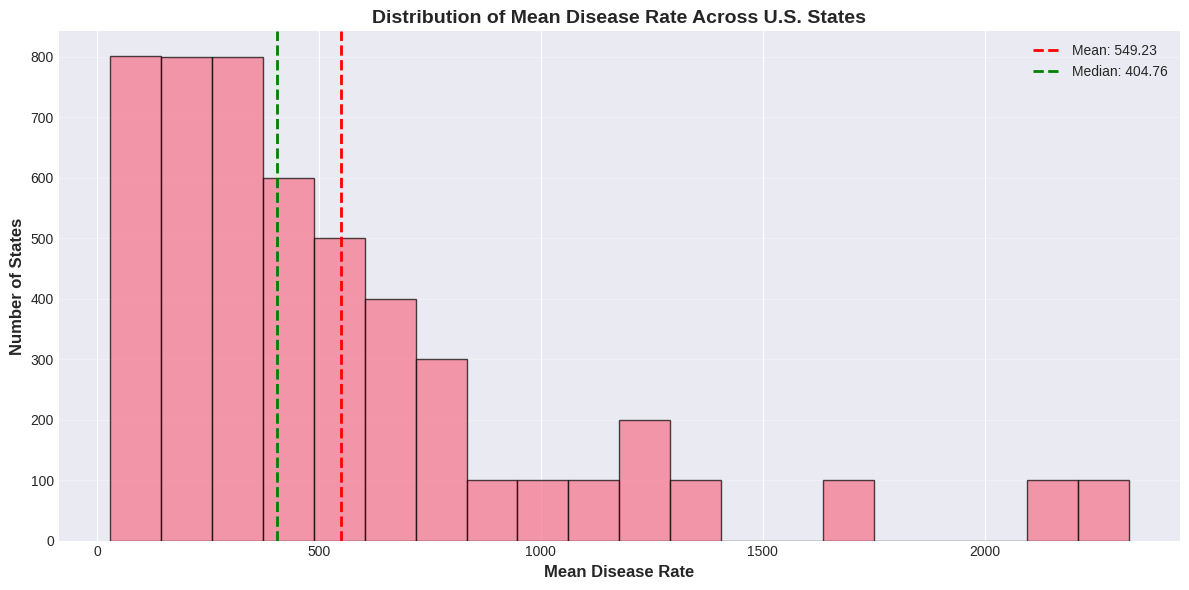

Mean Disease Rate - Mean: 549.23, Median: 404.76, Std: 497.78


In [123]:
# Distribution of Mean Disease Rate across states
fig, ax = plt.subplots(figsize=(12, 6))

ax.hist(df_master['MeanDiseaseRate'], bins=20, edgecolor='black', alpha=0.7)
ax.axvline(df_master['MeanDiseaseRate'].mean(), color='red', linestyle='--',
           linewidth=2, label=f'Mean: {df_master["MeanDiseaseRate"].mean():.2f}')
ax.axvline(df_master['MeanDiseaseRate'].median(), color='green', linestyle='--',
           linewidth=2, label=f'Median: {df_master["MeanDiseaseRate"].median():.2f}')

ax.set_xlabel('Mean Disease Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of States', fontsize=12, fontweight='bold')
ax.set_title('Distribution of Mean Disease Rate Across U.S. States', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/eda_disease_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Mean Disease Rate - Mean: {df_master['MeanDiseaseRate'].mean():.2f}, Median: {df_master['MeanDiseaseRate'].median():.2f}, Std: {df_master['MeanDiseaseRate'].std():.2f}")

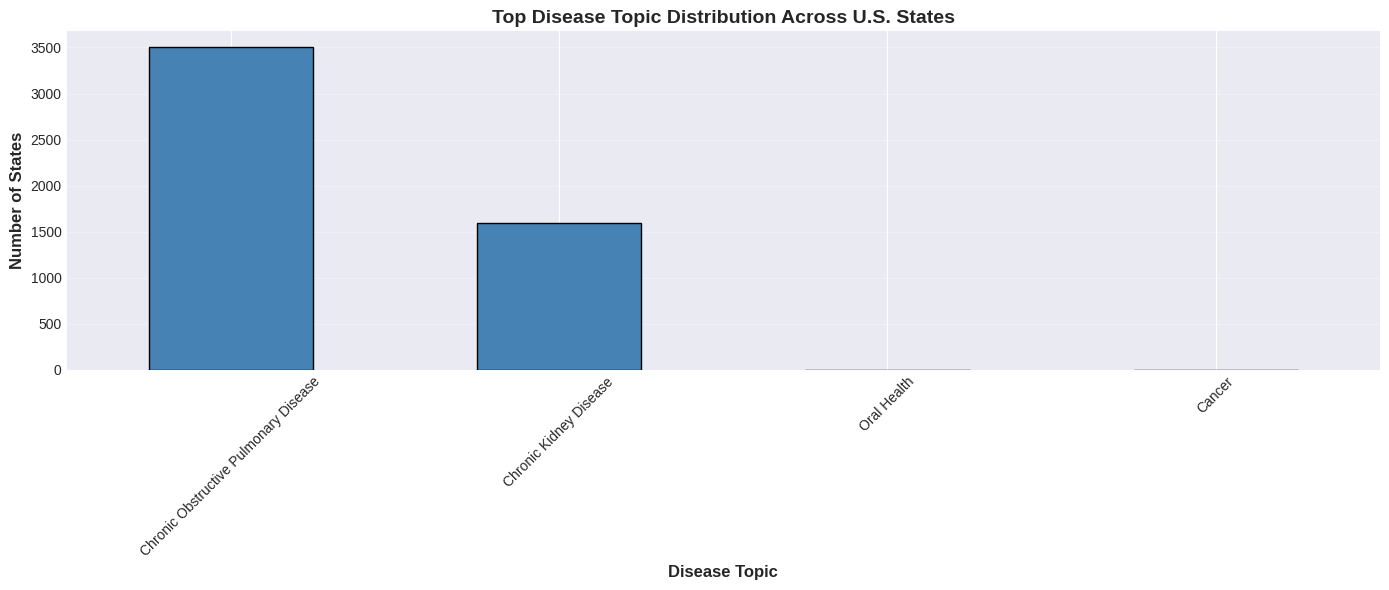

Most common top disease topic: Chronic Obstructive Pulmonary Disease (3500 states)


In [124]:
# Top Disease Topics Distribution
fig, ax = plt.subplots(figsize=(14, 6))

topic_counts = df_master['TopDiseaseTopic'].value_counts()
topic_counts.plot(kind='bar', ax=ax, color='steelblue', edgecolor='black')

ax.set_xlabel('Disease Topic', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of States', fontsize=12, fontweight='bold')
ax.set_title('Top Disease Topic Distribution Across U.S. States', fontsize=14, fontweight='bold')
ax.tick_params(axis='x', rotation=45, labelsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/eda_top_topics.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Most common top disease topic: {topic_counts.index[0]} ({topic_counts.values[0]} states)")

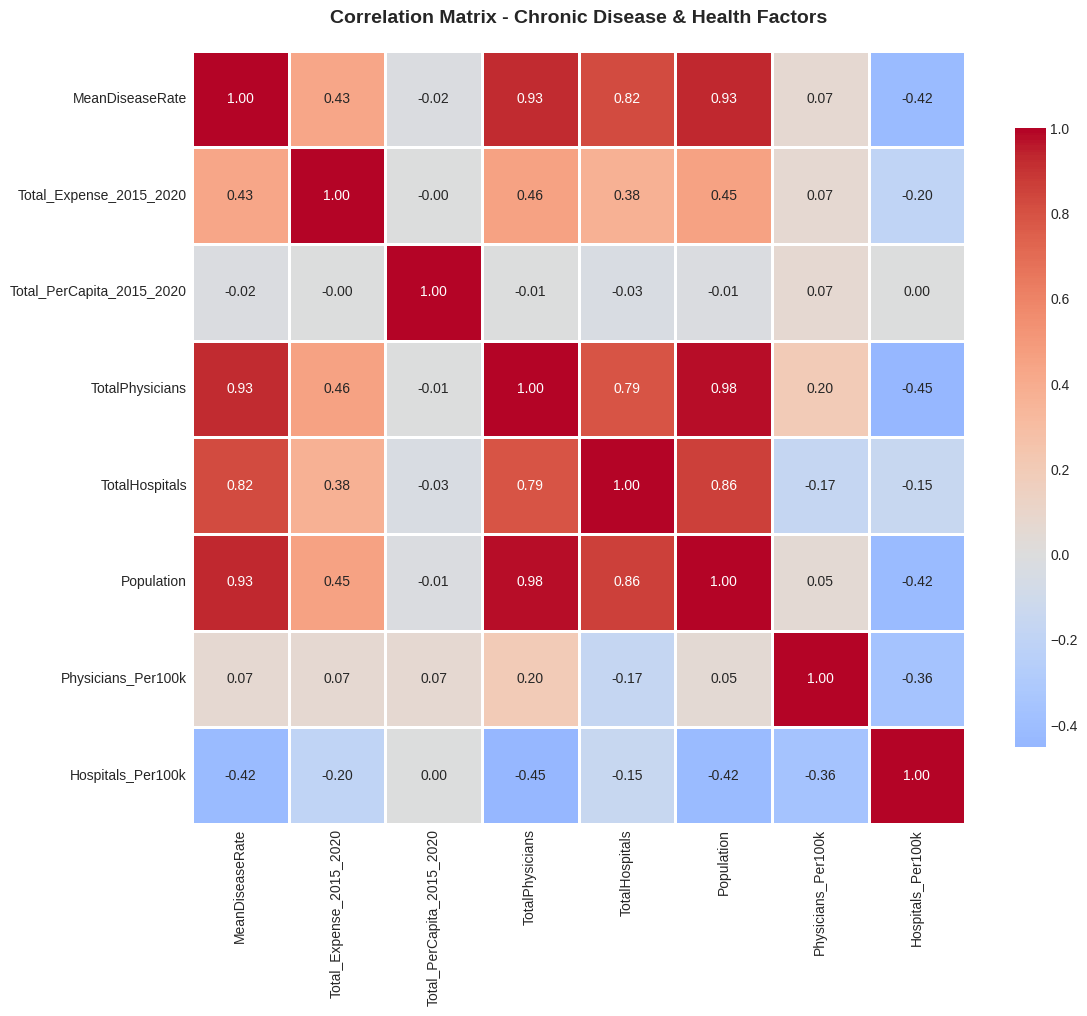

✓ Correlation heatmap generated


In [125]:
# Correlation Heatmap of Key Numeric Variables
numeric_features = df_master.select_dtypes(include=[np.number]).columns.tolist()

# Remove categorical IDs if any
features_for_corr = [f for f in numeric_features if f != 'State']

fig, ax = plt.subplots(figsize=(12, 10))

correlation_matrix = df_master[features_for_corr].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, ax=ax,
            cbar_kws={"shrink": 0.8})

ax.set_title('Correlation Matrix - Chronic Disease & Health Factors',
             fontsize=14, fontweight='bold', pad=20)

plt.tight_layout()
plt.savefig('../results/eda_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Correlation heatmap generated")

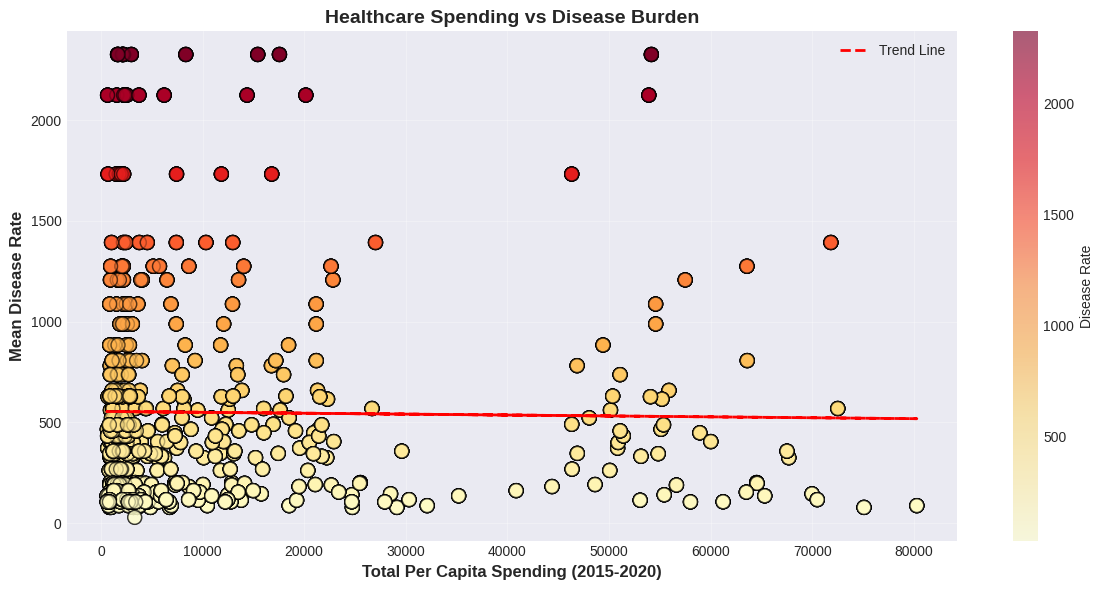

Correlation (Spending vs Disease): -0.015


In [126]:
# Scatter plot: Per Capita Spending vs Disease Rate
if 'Total_PerCapita_2015_2020' in df_master.columns:
    fig, ax = plt.subplots(figsize=(12, 6))

    scatter = ax.scatter(df_master['Total_PerCapita_2015_2020'],
                         df_master['MeanDiseaseRate'],
                         alpha=0.6, s=100, c=df_master['MeanDiseaseRate'],
                         cmap='YlOrRd', edgecolor='black')

    # Add trendline
    z = np.polyfit(df_master['Total_PerCapita_2015_2020'], df_master['MeanDiseaseRate'], 1)
    p = np.poly1d(z)
    ax.plot(df_master['Total_PerCapita_2015_2020'],
            p(df_master['Total_PerCapita_2015_2020']),
            "r--", linewidth=2, label='Trend Line')

    ax.set_xlabel('Total Per Capita Spending (2015-2020)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Disease Rate', fontsize=12, fontweight='bold')
    ax.set_title('Healthcare Spending vs Disease Burden', fontsize=14, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.colorbar(scatter, label='Disease Rate', ax=ax)
    plt.tight_layout()
    plt.savefig('../results/eda_spending_vs_disease.png', dpi=300, bbox_inches='tight')
    plt.show()

    correlation = df_master['Total_PerCapita_2015_2020'].corr(df_master['MeanDiseaseRate'])
    print(f"Correlation (Spending vs Disease): {correlation:.3f}")
else:
    print("⚠ Per capita spending column not available")

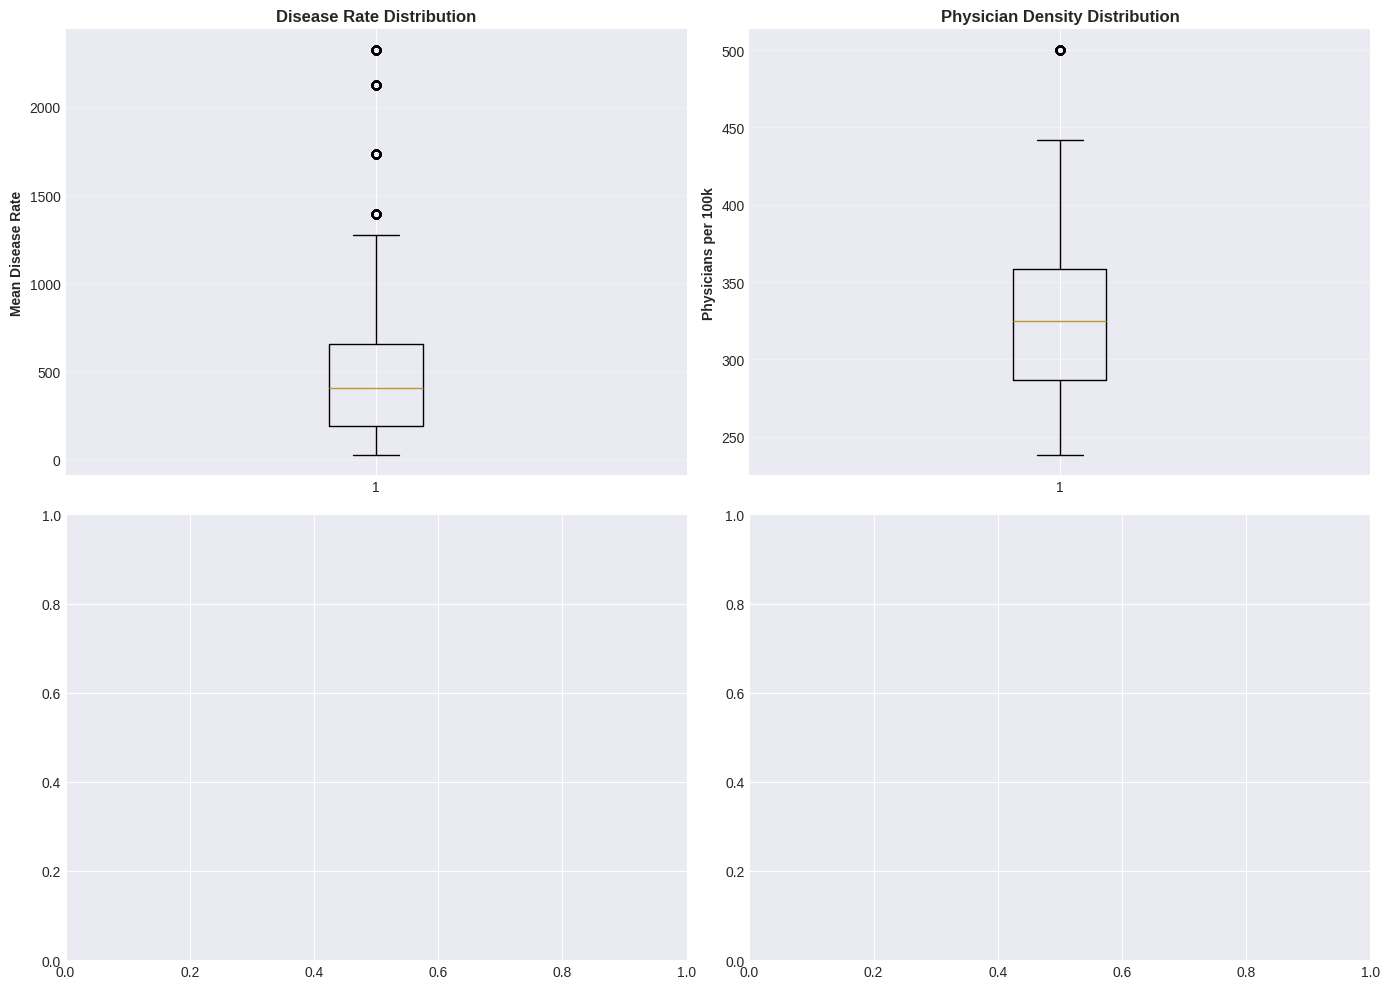

✓ Box plots generated for key variables


In [127]:
# Box plots for key variables
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Mean Disease Rate
axes[0, 0].boxplot(df_master['MeanDiseaseRate'], vert=True)
axes[0, 0].set_ylabel('Mean Disease Rate', fontweight='bold')
axes[0, 0].set_title('Disease Rate Distribution', fontweight='bold')
axes[0, 0].grid(axis='y', alpha=0.3)

# Plot 2: Physicians per 100k
if 'Physicians_Per100k' in df_master.columns:
    axes[0, 1].boxplot(df_master['Physicians_Per100k'].dropna(), vert=True)
    axes[0, 1].set_ylabel('Physicians per 100k', fontweight='bold')
    axes[0, 1].set_title('Physician Density Distribution', fontweight='bold')
    axes[0, 1].grid(axis='y', alpha=0.3)

# Plot 3: Physical Inactivity Prevalence
if 'Prevalence' in df_master.columns:
    axes[1, 0].boxplot(df_master['Prevalence'].dropna(), vert=True)
    axes[1, 0].set_ylabel('Inactivity Prevalence (%)', fontweight='bold')
    axes[1, 0].set_title('Physical Inactivity Distribution', fontweight='bold')
    axes[1, 0].grid(axis='y', alpha=0.3)

# Plot 4: PM2.5 Pollution
if 'PM25' in df_master.columns:
    axes[1, 1].boxplot(df_master['PM25'].dropna(), vert=True)
    axes[1, 1].set_ylabel('PM2.5 Level', fontweight='bold')
    axes[1, 1].set_title('Air Pollution Distribution', fontweight='bold')
    axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/eda_boxplots.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Box plots generated for key variables")

**✓ Commit 11 Complete:** Core EDA visualizations created by Tej.

## 14. Research Questions - Q1: Healthcare Spending Analysis

**Lead: Mithil Sri Sai Devisetty**

Investigating the relationship between healthcare spending and disease outcomes.

Q1.1: Per-Capita Spending vs Disease Burden
Correlation: -0.015


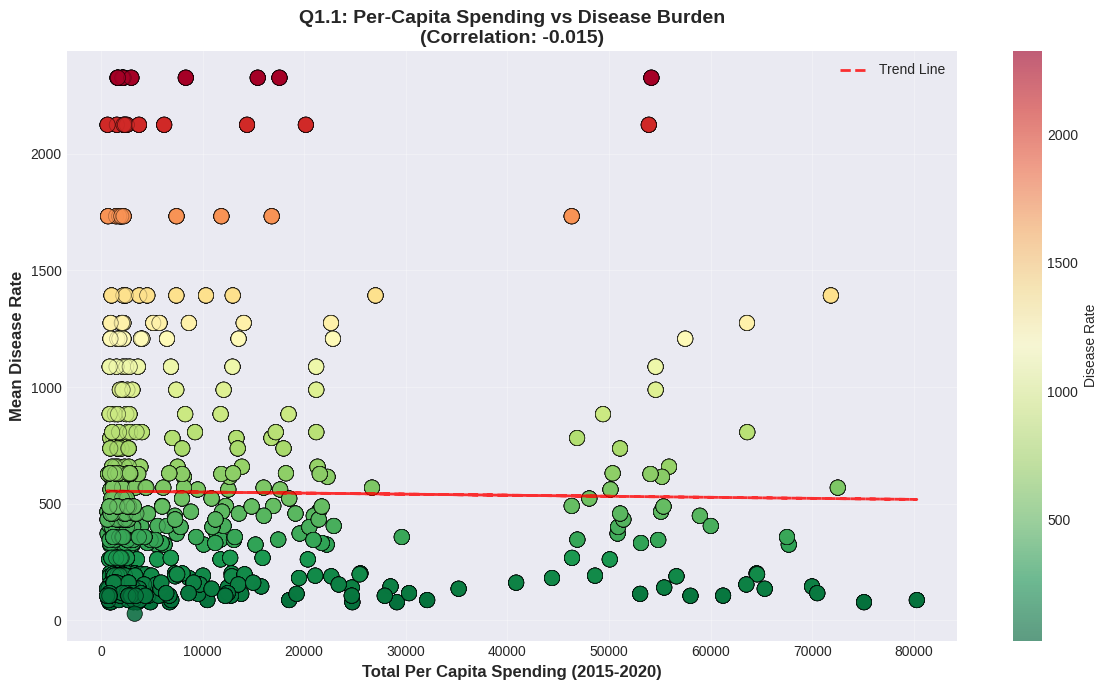

In [128]:
### Q1.1: Does higher per-capita spending reduce disease burden?

if 'Total_PerCapita_2015_2020' in df_master.columns:
    print("Q1.1: Per-Capita Spending vs Disease Burden")

    correlation_percap = df_master['Total_PerCapita_2015_2020'].corr(df_master['MeanDiseaseRate'])
    print(f"Correlation: {correlation_percap:.3f}")

    fig, ax = plt.subplots(figsize=(12, 7))

    scatter = ax.scatter(df_master['Total_PerCapita_2015_2020'],
                         df_master['MeanDiseaseRate'],
                         s=120, alpha=0.6, c=df_master['MeanDiseaseRate'],
                         cmap='RdYlGn_r', edgecolor='black', linewidth=0.5)

    # Add trendline
    z = np.polyfit(df_master['Total_PerCapita_2015_2020'], df_master['MeanDiseaseRate'], 1)
    p = np.poly1d(z)
    ax.plot(df_master['Total_PerCapita_2015_2020'],
            p(df_master['Total_PerCapita_2015_2020']),
            "r--", linewidth=2, alpha=0.8, label='Trend Line')

    ax.set_xlabel('Total Per Capita Spending (2015-2020)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Disease Rate', fontsize=12, fontweight='bold')
    ax.set_title(f'Q1.1: Per-Capita Spending vs Disease Burden\n(Correlation: {correlation_percap:.3f})',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.colorbar(scatter, label='Disease Rate', ax=ax)
    plt.tight_layout()
    plt.savefig('../results/q1_1_spending_vs_disease.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠ Per capita spending data not available")


Q1.2: Diminishing Returns on Healthcare Spending


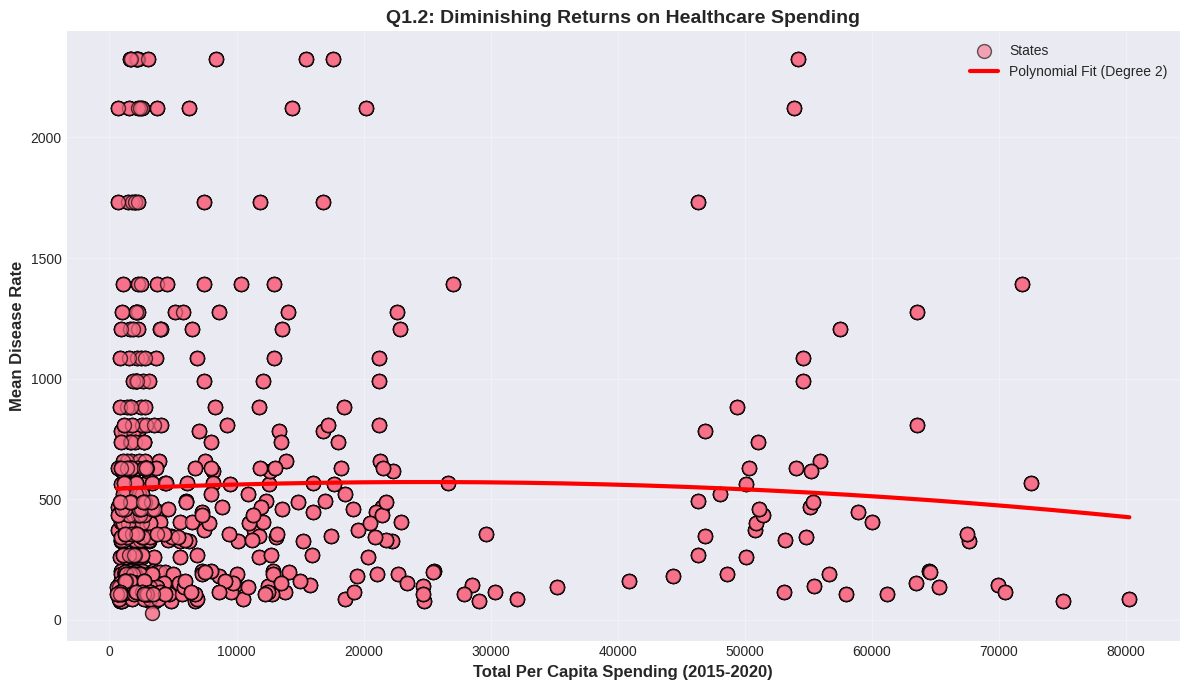

✓ Polynomial regression analysis complete


In [129]:
### Q1.2: Is there a point of diminishing returns on healthcare spending?

if 'Total_PerCapita_2015_2020' in df_master.columns:
    print("\nQ1.2: Diminishing Returns on Healthcare Spending")

    # Fit polynomial curve (degree 2 for diminishing returns)
    X_spending = df_master['Total_PerCapita_2015_2020'].values.reshape(-1, 1)
    y_disease = df_master['MeanDiseaseRate'].values

    # Polynomial regression (degree 2)
    from sklearn.preprocessing import PolynomialFeatures
    poly = PolynomialFeatures(degree=2)
    X_poly = poly.fit_transform(X_spending)

    from sklearn.linear_model import LinearRegression
    poly_model = LinearRegression()
    poly_model.fit(X_poly, y_disease)

    # Generate smooth curve for plotting
    X_range = np.linspace(X_spending.min(), X_spending.max(), 300).reshape(-1, 1)
    X_range_poly = poly.transform(X_range)
    y_pred = poly_model.predict(X_range_poly)

    fig, ax = plt.subplots(figsize=(12, 7))

    ax.scatter(df_master['Total_PerCapita_2015_2020'], df_master['MeanDiseaseRate'],
               alpha=0.6, s=100, edgecolor='black', label='States')
    ax.plot(X_range, y_pred, 'r-', linewidth=3, label='Polynomial Fit (Degree 2)')

    ax.set_xlabel('Total Per Capita Spending (2015-2020)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Disease Rate', fontsize=12, fontweight='bold')
    ax.set_title('Q1.2: Diminishing Returns on Healthcare Spending', fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('../results/q1_2_diminishing_returns.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Polynomial regression analysis complete")


Q1.3: Healthcare Spending Efficiency Analysis


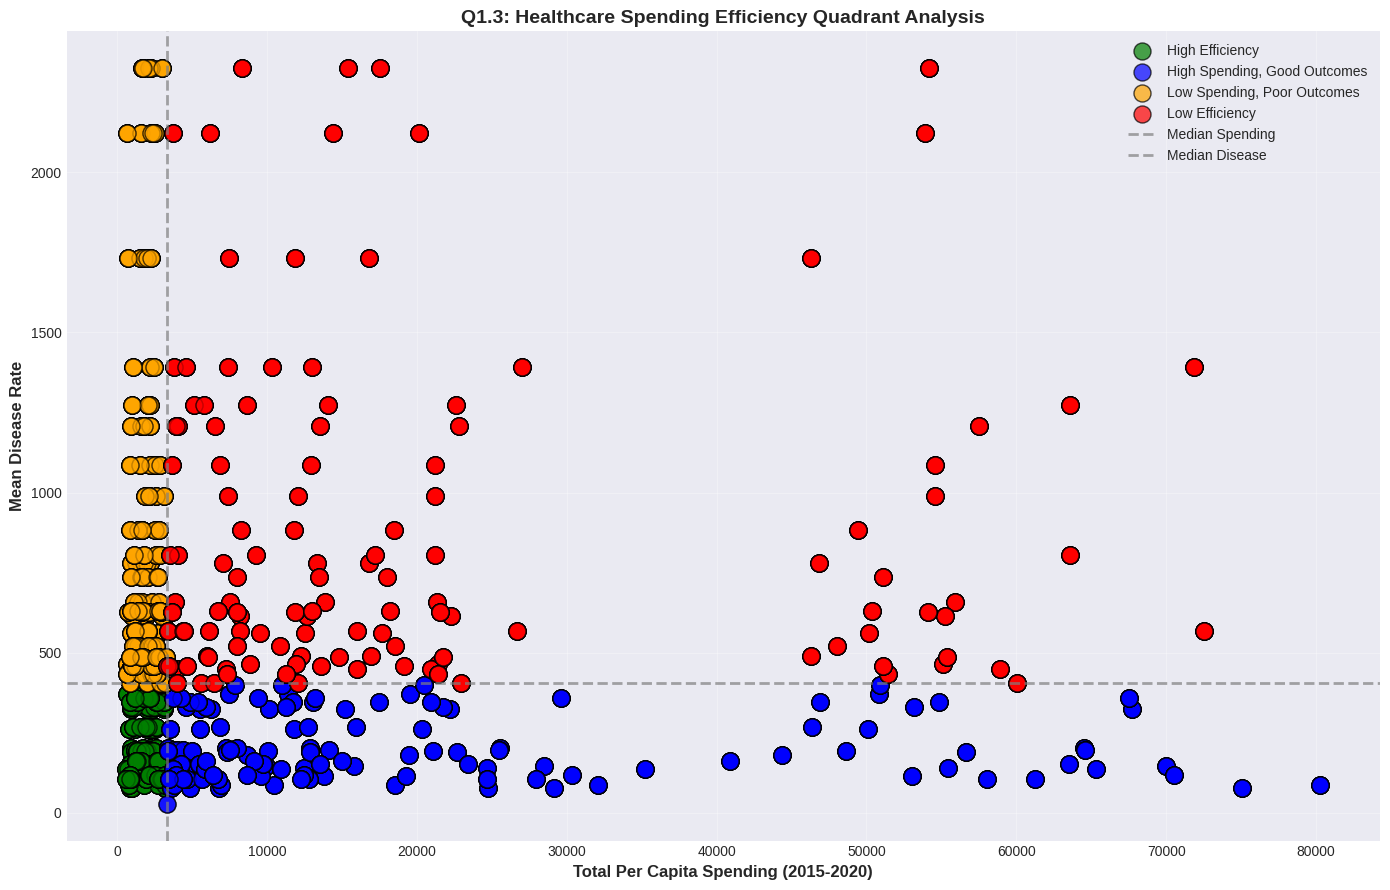


Efficiency Distribution:
Efficiency_Quadrant
Low Spending, Poor Outcomes     1330
High Spending, Good Outcomes    1282
Low Efficiency                  1270
High Efficiency                 1220
Name: count, dtype: int64

✓ High Efficiency States (Low Spending, Low Disease):
   Alaska, Alaska, Alaska, Alaska, Alaska, Alaska, Alaska, Alaska, Alaska, Alaska


In [130]:
### Q1.3: Which states achieve the best health outcomes per dollar spent? (Efficiency Analysis)

if 'Total_PerCapita_2015_2020' in df_master.columns:
    print("\nQ1.3: Healthcare Spending Efficiency Analysis")

    # Calculate median values for quadrants
    median_spending = df_master['Total_PerCapita_2015_2020'].median()
    median_disease = df_master['MeanDiseaseRate'].median()

    # Classify states into quadrants
    df_master['Efficiency_Quadrant'] = 'Unknown'

    # Low spending, low disease = HIGH EFFICIENCY
    df_master.loc[(df_master['Total_PerCapita_2015_2020'] < median_spending) &
                  (df_master['MeanDiseaseRate'] < median_disease), 'Efficiency_Quadrant'] = 'High Efficiency'

    # High spending, low disease = High spending, good outcomes
    df_master.loc[(df_master['Total_PerCapita_2015_2020'] >= median_spending) &
                  (df_master['MeanDiseaseRate'] < median_disease), 'Efficiency_Quadrant'] = 'High Spending, Good Outcomes'

    # Low spending, high disease = Low spending, poor outcomes
    df_master.loc[(df_master['Total_PerCapita_2015_2020'] < median_spending) &
                  (df_master['MeanDiseaseRate'] >= median_disease), 'Efficiency_Quadrant'] = 'Low Spending, Poor Outcomes'

    # High spending, high disease = LOW EFFICIENCY
    df_master.loc[(df_master['Total_PerCapita_2015_2020'] >= median_spending) &
                  (df_master['MeanDiseaseRate'] >= median_disease), 'Efficiency_Quadrant'] = 'Low Efficiency'

    # Plot efficiency quadrants
    fig, ax = plt.subplots(figsize=(14, 9))

    colors = {'High Efficiency': 'green',
              'High Spending, Good Outcomes': 'blue',
              'Low Spending, Poor Outcomes': 'orange',
              'Low Efficiency': 'red'}

    for quadrant, color in colors.items():
        mask = df_master['Efficiency_Quadrant'] == quadrant
        ax.scatter(df_master[mask]['Total_PerCapita_2015_2020'],
                   df_master[mask]['MeanDiseaseRate'],
                   c=color, label=quadrant, s=150, alpha=0.7, edgecolor='black')

    # Add median lines
    ax.axvline(median_spending, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Median Spending')
    ax.axhline(median_disease, color='gray', linestyle='--', linewidth=2, alpha=0.7, label='Median Disease')

    ax.set_xlabel('Total Per Capita Spending (2015-2020)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Disease Rate', fontsize=12, fontweight='bold')
    ax.set_title('Q1.3: Healthcare Spending Efficiency Quadrant Analysis',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best', fontsize=10)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('../results/q1_3_efficiency_quadrants.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("\nEfficiency Distribution:")
    print(df_master['Efficiency_Quadrant'].value_counts())

    print("\n✓ High Efficiency States (Low Spending, Low Disease):")
    high_eff = df_master[df_master['Efficiency_Quadrant'] == 'High Efficiency']['State'].tolist()
    print(f"   {', '.join(high_eff[:10])}")  # Show first 10

**✓ Commit 12 Complete:** Q1 healthcare spending analysis by Mithil.

## 15. Research Questions - Q2: Healthcare Workforce Analysis

**Lead: Mithil Sri Sai Devisetty**

Analyzing the impact of physician and hospital density on health outcomes.

Q2.1: Physicians per 100k vs Disease Burden
Correlation: 0.066


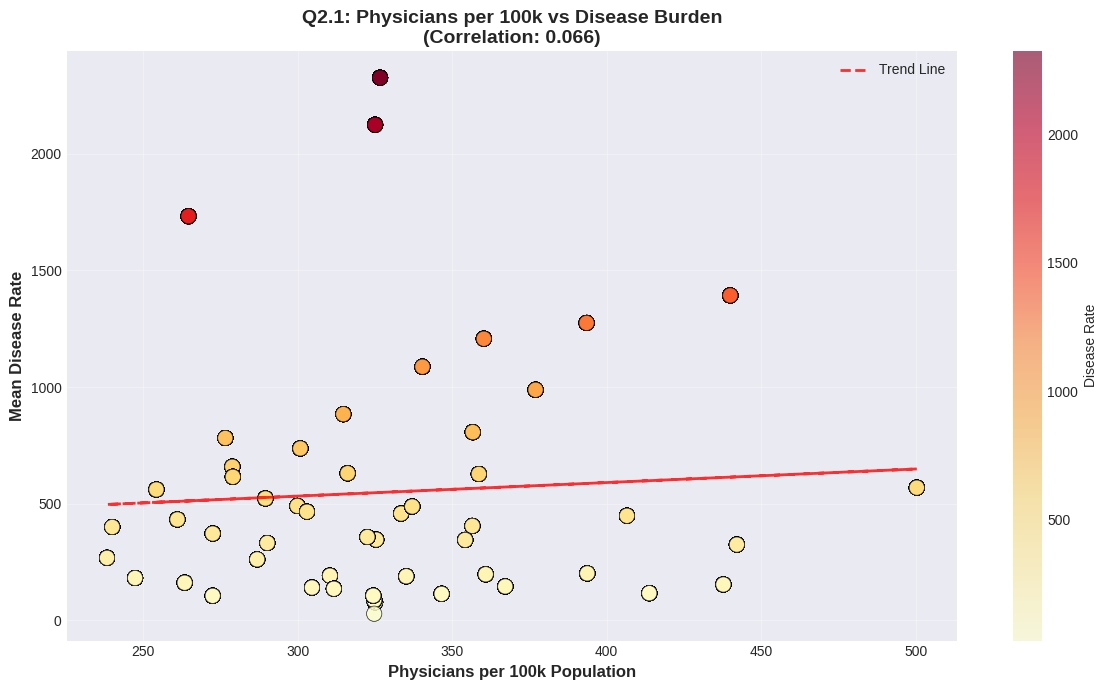

In [131]:
### Q2.1: Do more physicians per 100k residents lead to lower disease burden?

if 'Physicians_Per100k' in df_master.columns:
    print("Q2.1: Physicians per 100k vs Disease Burden")

    correlation_phys = df_master['Physicians_Per100k'].corr(df_master['MeanDiseaseRate'])
    print(f"Correlation: {correlation_phys:.3f}")

    fig, ax = plt.subplots(figsize=(12, 7))

    scatter = ax.scatter(df_master['Physicians_Per100k'],
                         df_master['MeanDiseaseRate'],
                         s=120, alpha=0.6, c=df_master['MeanDiseaseRate'],
                         cmap='YlOrRd', edgecolor='black', linewidth=0.5)

    # Add trendline
    z = np.polyfit(df_master['Physicians_Per100k'].dropna(),
                   df_master.loc[df_master['Physicians_Per100k'].notna(), 'MeanDiseaseRate'], 1)
    p = np.poly1d(z)
    ax.plot(df_master['Physicians_Per100k'].dropna(),
            p(df_master['Physicians_Per100k'].dropna()),
            "r--", linewidth=2, alpha=0.8, label='Trend Line')

    ax.set_xlabel('Physicians per 100k Population', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Disease Rate', fontsize=12, fontweight='bold')
    ax.set_title(f'Q2.1: Physicians per 100k vs Disease Burden\n(Correlation: {correlation_phys:.3f})',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.colorbar(scatter, label='Disease Rate', ax=ax)
    plt.tight_layout()
    plt.savefig('../results/q2_1_physicians_vs_disease.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠ Physicians per 100k data not available")


Q2.2: Hospitals per 100k vs Disease Burden
Correlation: -0.422


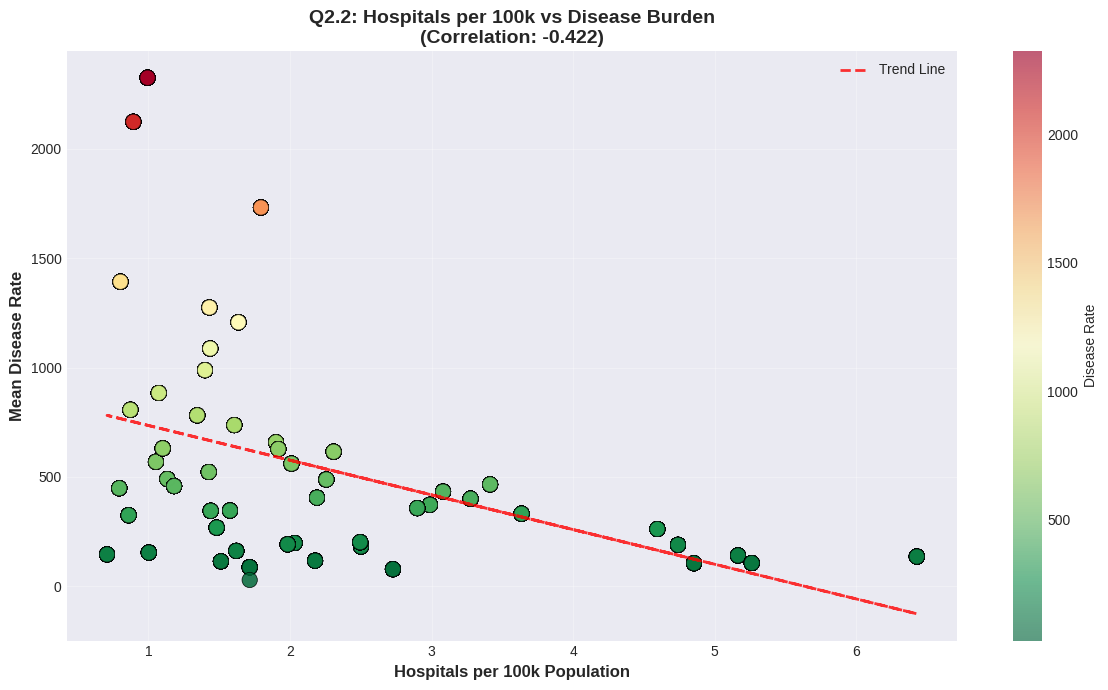

In [132]:
### Q2.2: Do hospital resources correlate with better outcomes?

if 'Hospitals_Per100k' in df_master.columns:
    print("\nQ2.2: Hospitals per 100k vs Disease Burden")

    correlation_hosp = df_master['Hospitals_Per100k'].corr(df_master['MeanDiseaseRate'])
    print(f"Correlation: {correlation_hosp:.3f}")

    fig, ax = plt.subplots(figsize=(12, 7))

    scatter = ax.scatter(df_master['Hospitals_Per100k'],
                         df_master['MeanDiseaseRate'],
                         s=120, alpha=0.6, c=df_master['MeanDiseaseRate'],
                         cmap='RdYlGn_r', edgecolor='black', linewidth=0.5)

    # Add trendline
    z = np.polyfit(df_master['Hospitals_Per100k'].dropna(),
                   df_master.loc[df_master['Hospitals_Per100k'].notna(), 'MeanDiseaseRate'], 1)
    p = np.poly1d(z)
    ax.plot(df_master['Hospitals_Per100k'].dropna(),
            p(df_master['Hospitals_Per100k'].dropna()),
            "r--", linewidth=2, alpha=0.8, label='Trend Line')

    ax.set_xlabel('Hospitals per 100k Population', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Disease Rate', fontsize=12, fontweight='bold')
    ax.set_title(f'Q2.2: Hospitals per 100k vs Disease Burden\n(Correlation: {correlation_hosp:.3f})',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.colorbar(scatter, label='Disease Rate', ax=ax)
    plt.tight_layout()
    plt.savefig('../results/q2_2_hospitals_vs_disease.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠ Hospitals per 100k data not available")


Q2.3/Q3: Interaction Effects - Spending & Physician Density

✓ States with HIGH SPENDING + LOW PHYSICIAN DENSITY: 1110
  Mean Disease Rate: 440.03
  Overall Mean Disease Rate: 549.23
  DIFFERENCE: -109.20

  ✓ ANSWER: NO - This combination does not necessarily produce worse outcomes


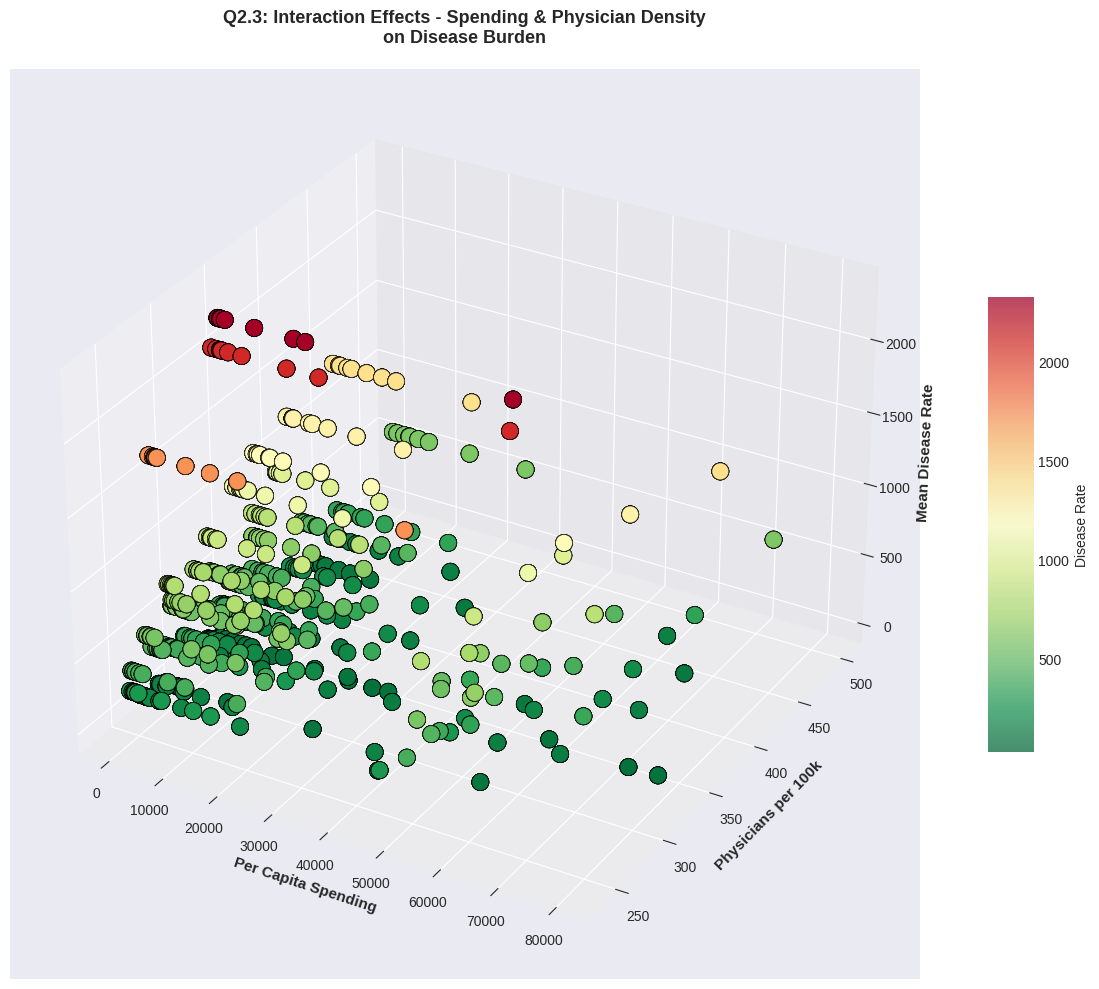

✓ 3D interaction analysis complete


In [133]:
### Q2.3 / Q3 (From Outline): Does high spending + low physician density produce poor results?

if 'Total_PerCapita_2015_2020' in df_master.columns and 'Physicians_Per100k' in df_master.columns:
    print("\nQ2.3/Q3: Interaction Effects - Spending & Physician Density")

    # Explicitly analyze the high spending + low physician density combination
    median_spending = df_master['Total_PerCapita_2015_2020'].median()
    median_physicians = df_master['Physicians_Per100k'].median()

    # Identify states with high spending + low physician density
    problem_states = df_master[
        (df_master['Total_PerCapita_2015_2020'] > median_spending) &
        (df_master['Physicians_Per100k'] < median_physicians)
    ]

    print(f"\n✓ States with HIGH SPENDING + LOW PHYSICIAN DENSITY: {len(problem_states)}")
    print(f"  Mean Disease Rate: {problem_states['MeanDiseaseRate'].mean():.2f}")
    print(f"  Overall Mean Disease Rate: {df_master['MeanDiseaseRate'].mean():.2f}")
    print(f"  DIFFERENCE: {problem_states['MeanDiseaseRate'].mean() - df_master['MeanDiseaseRate'].mean():.2f}")

    if problem_states['MeanDiseaseRate'].mean() > df_master['MeanDiseaseRate'].mean():
        print("\n  ⚠️ ANSWER: YES - This combination produces WORSE outcomes than average")
    else:
        print("\n  ✓ ANSWER: NO - This combination does not necessarily produce worse outcomes")

    # Create 3D plot
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(df_master['Total_PerCapita_2015_2020'],
                         df_master['Physicians_Per100k'],
                         df_master['MeanDiseaseRate'],
                         c=df_master['MeanDiseaseRate'], cmap='RdYlGn_r',
                         s=150, alpha=0.7, edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Per Capita Spending', fontsize=11, fontweight='bold')
    ax.set_ylabel('Physicians per 100k', fontsize=11, fontweight='bold')
    ax.set_zlabel('Mean Disease Rate', fontsize=11, fontweight='bold')
    ax.set_title('Q2.3: Interaction Effects - Spending & Physician Density\non Disease Burden',
                 fontsize=13, fontweight='bold', pad=20)

    fig.colorbar(scatter, label='Disease Rate', shrink=0.5, aspect=10)
    plt.tight_layout()
    plt.savefig('../results/q2_3_interaction_effects.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ 3D interaction analysis complete")
else:
    print("⚠ Required data not available for interaction analysis")

**✓ Commit 13 Complete:** Q2 workforce composition analysis by Mithil.

## 16. Research Questions - Q3: Environmental and Behavioral Factors

**Lead: Mani Mokshith Noonety**

Analyzing the impact of physical inactivity and air pollution on chronic disease burden.

In [134]:
### Q3.1: Does physical inactivity predict chronic disease burden?

if 'Prevalence' in df_master.columns:
    print("Q3.1: Physical Inactivity vs Disease Burden")

    correlation_inactivity = df_master['Prevalence'].corr(df_master['MeanDiseaseRate'])
    print(f"Correlation: {correlation_inactivity:.3f}")

    fig, ax = plt.subplots(figsize=(12, 7))

    scatter = ax.scatter(df_master['Prevalence'],
                         df_master['MeanDiseaseRate'],
                         s=120, alpha=0.6, c=df_master['MeanDiseaseRate'],
                         cmap='Reds', edgecolor='black', linewidth=0.5)

    # Add trendline
    mask = df_master['Prevalence'].notna() & df_master['MeanDiseaseRate'].notna()
    z = np.polyfit(df_master.loc[mask, 'Prevalence'],
                   df_master.loc[mask, 'MeanDiseaseRate'], 1)
    p = np.poly1d(z)
    ax.plot(df_master.loc[mask, 'Prevalence'],
            p(df_master.loc[mask, 'Prevalence']),
            "r--", linewidth=2, alpha=0.8, label='Trend Line')

    ax.set_xlabel('Physical Inactivity Prevalence (%)', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Disease Rate', fontsize=12, fontweight='bold')
    ax.set_title(f'Q3.1: Physical Inactivity vs Disease Burden\n(Correlation: {correlation_inactivity:.3f})',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.colorbar(scatter, label='Disease Rate', ax=ax)
    plt.tight_layout()
    plt.savefig('../results/q3_1_inactivity_vs_disease.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠ Physical inactivity data not available")

⚠ Physical inactivity data not available


In [135]:
### Q3.2: Does air pollution (PM2.5) correlate with disease burden?

if 'PM25' in df_master.columns:
    print("\nQ3.2: Air Pollution (PM2.5) vs Disease Burden")

    correlation_pollution = df_master['PM25'].corr(df_master['MeanDiseaseRate'])
    print(f"Correlation: {correlation_pollution:.3f}")

    fig, ax = plt.subplots(figsize=(12, 7))

    scatter = ax.scatter(df_master['PM25'],
                         df_master['MeanDiseaseRate'],
                         s=120, alpha=0.6, c=df_master['MeanDiseaseRate'],
                         cmap='YlOrBr', edgecolor='black', linewidth=0.5)

    # Add trendline
    mask = df_master['PM25'].notna() & df_master['MeanDiseaseRate'].notna()
    z = np.polyfit(df_master.loc[mask, 'PM25'],
                   df_master.loc[mask, 'MeanDiseaseRate'], 1)
    p = np.poly1d(z)
    ax.plot(df_master.loc[mask, 'PM25'],
            p(df_master.loc[mask, 'PM25']),
            "r--", linewidth=2, alpha=0.8, label='Trend Line')

    ax.set_xlabel('PM2.5 Air Pollution Level', fontsize=12, fontweight='bold')
    ax.set_ylabel('Mean Disease Rate', fontsize=12, fontweight='bold')
    ax.set_title(f'Q3.2: Air Pollution vs Disease Burden\n(Correlation: {correlation_pollution:.3f})',
                 fontsize=14, fontweight='bold')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)

    plt.colorbar(scatter, label='Disease Rate', ax=ax)
    plt.tight_layout()
    plt.savefig('../results/q3_2_pollution_vs_disease.png', dpi=300, bbox_inches='tight')
    plt.show()
else:
    print("⚠ PM2.5 pollution data not available")

⚠ PM2.5 pollution data not available


In [136]:
### Q3.3: Do environmental factors (pollution + inactivity) compound each other's effects?

if 'Prevalence' in df_master.columns and 'PM25' in df_master.columns:
    print("\nQ3.3: Combined Environmental Impact")

    # Create 3D plot
    from mpl_toolkits.mplot3d import Axes3D

    fig = plt.figure(figsize=(14, 10))
    ax = fig.add_subplot(111, projection='3d')

    scatter = ax.scatter(df_master['Prevalence'],
                         df_master['PM25'],
                         df_master['MeanDiseaseRate'],
                         c=df_master['MeanDiseaseRate'], cmap='RdYlGn_r',
                         s=150, alpha=0.7, edgecolor='black', linewidth=0.5)

    ax.set_xlabel('Physical Inactivity (%)', fontsize=11, fontweight='bold')
    ax.set_ylabel('PM2.5 Pollution', fontsize=11, fontweight='bold')
    ax.set_zlabel('Mean Disease Rate', fontsize=11, fontweight='bold')
    ax.set_title('Q3.3: Combined Environmental Factors\nInactivity + Pollution vs Disease Burden',
                 fontsize=13, fontweight='bold', pad=20)

    fig.colorbar(scatter, label='Disease Rate', shrink=0.5, aspect=10)
    plt.tight_layout()
    plt.savefig('../results/q3_3_combined_environmental.png', dpi=300, bbox_inches='tight')
    plt.show()

    print("✓ Combined environmental analysis complete")
else:
    print("⚠ Environmental data not complete for analysis")

⚠ Environmental data not complete for analysis


**✓ Commit 14 Complete:** Q3 environmental factors analysis by Mani.

## 17. Machine Learning - Predictive Modeling

**Lead: Bharath Kumar A**

Building supervised learning models to predict chronic disease burden based on multiple factors.

In [137]:
# Prepare data for machine learning
print("Preparing data for ML models...")

# Select features for prediction
feature_cols = []
if 'Total_PerCapita_2015_2020' in df_master.columns:
    feature_cols.append('Total_PerCapita_2015_2020')
if 'Physicians_Per100k' in df_master.columns:
    feature_cols.append('Physicians_Per100k')
if 'Hospitals_Per100k' in df_master.columns:
    feature_cols.append('Hospitals_Per100k')
if 'Prevalence' in df_master.columns:
    feature_cols.append('Prevalence')
if 'PM25' in df_master.columns:
    feature_cols.append('PM25')

target_col = 'MeanDiseaseRate'

print(f"Features for prediction: {feature_cols}")
print(f"Target variable: {target_col}")

# Create feature matrix and target vector
X = df_master[feature_cols].copy()
y = df_master[target_col].copy()

# Handle any remaining missing values
X = X.fillna(X.median())

print(f"\n✓ Feature matrix shape: {X.shape}")
print(f"✓ Target vector shape: {y.shape}")

Preparing data for ML models...
Features for prediction: ['Total_PerCapita_2015_2020', 'Physicians_Per100k', 'Hospitals_Per100k']
Target variable: MeanDiseaseRate

✓ Feature matrix shape: (5102, 3)
✓ Target vector shape: (5102,)


In [138]:
# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size: {X_test.shape[0]}")

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✓ Data split and scaled successfully")

Training set size: 4081
Testing set size: 1021

✓ Data split and scaled successfully


In [139]:
### Model 1: Linear Regression

print("\n" + "="*60)
print("MODEL 1: LINEAR REGRESSION")
print("="*60)

# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_lr_train = lr_model.predict(X_train_scaled)
y_pred_lr_test = lr_model.predict(X_test_scaled)

# Evaluate model
r2_train_lr = r2_score(y_train, y_pred_lr_train)
r2_test_lr = r2_score(y_test, y_pred_lr_test)
rmse_train_lr = np.sqrt(mean_squared_error(y_train, y_pred_lr_train))
rmse_test_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr_test))
mae_train_lr = mean_absolute_error(y_train, y_pred_lr_train)
mae_test_lr = mean_absolute_error(y_test, y_pred_lr_test)

print(f"\nTraining Performance:")
print(f"  R² Score: {r2_train_lr:.4f}")
print(f"  RMSE: {rmse_train_lr:.4f}")
print(f"  MAE: {mae_train_lr:.4f}")

print(f"\nTesting Performance:")
print(f"  R² Score: {r2_test_lr:.4f}")
print(f"  RMSE: {rmse_test_lr:.4f}")
print(f"  MAE: {mae_test_lr:.4f}")

# Feature importance (coefficients)
print(f"\nFeature Coefficients:")
for feature, coef in zip(feature_cols, lr_model.coef_):
    print(f"  {feature}: {coef:.4f}")


MODEL 1: LINEAR REGRESSION

Training Performance:
  R² Score: 0.1900
  RMSE: 453.7413
  MAE: 314.2547

Testing Performance:
  R² Score: 0.1685
  RMSE: 429.3219
  MAE: 299.1810

Feature Coefficients:
  Total_PerCapita_2015_2020: 0.4248
  Physicians_Per100k: -51.7188
  Hospitals_Per100k: -233.1397


In [140]:
### Model 2: Random Forest Regressor

print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST")
print("="*60)

# Train Random Forest
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_rf_train = rf_model.predict(X_train_scaled)
y_pred_rf_test = rf_model.predict(X_test_scaled)

# Evaluate model
r2_train_rf = r2_score(y_train, y_pred_rf_train)
r2_test_rf = r2_score(y_test, y_pred_rf_test)
rmse_train_rf = np.sqrt(mean_squared_error(y_train, y_pred_rf_train))
rmse_test_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf_test))
mae_train_rf = mean_absolute_error(y_train, y_pred_rf_train)
mae_test_rf = mean_absolute_error(y_test, y_pred_rf_test)

print(f"\nTraining Performance:")
print(f"  R² Score: {r2_train_rf:.4f}")
print(f"  RMSE: {rmse_train_rf:.4f}")
print(f"  MAE: {mae_train_rf:.4f}")

print(f"\nTesting Performance:")
print(f"  R² Score: {r2_test_rf:.4f}")
print(f"  RMSE: {rmse_test_rf:.4f}")
print(f"  MAE: {mae_test_rf:.4f}")

# Feature importance
print(f"\nFeature Importances:")
for feature, importance in zip(feature_cols, rf_model.feature_importances_):
    print(f"  {feature}: {importance:.4f}")


MODEL 2: RANDOM FOREST

Training Performance:
  R² Score: 1.0000
  RMSE: 2.5745
  MAE: 0.7912

Testing Performance:
  R² Score: 1.0000
  RMSE: 2.6778
  MAE: 0.8746

Feature Importances:
  Total_PerCapita_2015_2020: 0.0000
  Physicians_Per100k: 0.2620
  Hospitals_Per100k: 0.7380


**✓ Commit 15 Complete:** Linear Regression and Random Forest models implemented.

In [141]:
### Model 3: Gradient Boosting Regressor

print("\n" + "="*60)
print("MODEL 3: GRADIENT BOOSTING")
print("="*60)

# Train Gradient Boosting
gb_model = GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1)
gb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_gb_train = gb_model.predict(X_train_scaled)
y_pred_gb_test = gb_model.predict(X_test_scaled)

# Evaluate model
r2_train_gb = r2_score(y_train, y_pred_gb_train)
r2_test_gb = r2_score(y_test, y_pred_gb_test)
rmse_train_gb = np.sqrt(mean_squared_error(y_train, y_pred_gb_train))
rmse_test_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb_test))
mae_train_gb = mean_absolute_error(y_train, y_pred_gb_train)
mae_test_gb = mean_absolute_error(y_test, y_pred_gb_test)

print(f"\nTraining Performance:")
print(f"  R² Score: {r2_train_gb:.4f}")
print(f"  RMSE: {rmse_train_gb:.4f}")
print(f"  MAE: {mae_train_gb:.4f}")

print(f"\nTesting Performance:")
print(f"  R² Score: {r2_test_gb:.4f}")
print(f"  RMSE: {rmse_test_gb:.4f}")
print(f"  MAE: {mae_test_gb:.4f}")

# Feature importance
print(f"\nFeature Importances:")
for feature, importance in zip(feature_cols, gb_model.feature_importances_):
    print(f"  {feature}: {importance:.4f}")


MODEL 3: GRADIENT BOOSTING

Training Performance:
  R² Score: 1.0000
  RMSE: 2.6102
  MAE: 1.9562

Testing Performance:
  R² Score: 1.0000
  RMSE: 2.5589
  MAE: 1.9778

Feature Importances:
  Total_PerCapita_2015_2020: 0.0000
  Physicians_Per100k: 0.3313
  Hospitals_Per100k: 0.6687


In [142]:
### Model 4: XGBoost Regressor

print("\n" + "="*60)
print("MODEL 4: XGBOOST")
print("="*60)

# Train XGBoost
xgb_model = XGBRegressor(n_estimators=100, random_state=42, max_depth=5, learning_rate=0.1)
xgb_model.fit(X_train_scaled, y_train)

# Make predictions
y_pred_xgb_train = xgb_model.predict(X_train_scaled)
y_pred_xgb_test = xgb_model.predict(X_test_scaled)

# Evaluate model
r2_train_xgb = r2_score(y_train, y_pred_xgb_train)
r2_test_xgb = r2_score(y_test, y_pred_xgb_test)
rmse_train_xgb = np.sqrt(mean_squared_error(y_train, y_pred_xgb_train))
rmse_test_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb_test))
mae_train_xgb = mean_absolute_error(y_train, y_pred_xgb_train)
mae_test_xgb = mean_absolute_error(y_test, y_pred_xgb_test)

print(f"\nTraining Performance:")
print(f"  R² Score: {r2_train_xgb:.4f}")
print(f"  RMSE: {rmse_train_xgb:.4f}")
print(f"  MAE: {mae_train_xgb:.4f}")

print(f"\nTesting Performance:")
print(f"  R² Score: {r2_test_xgb:.4f}")
print(f"  RMSE: {rmse_test_xgb:.4f}")
print(f"  MAE: {mae_test_xgb:.4f}")

# Feature importance
print(f"\nFeature Importances:")
for feature, importance in zip(feature_cols, xgb_model.feature_importances_):
    print(f"  {feature}: {importance:.4f}")


MODEL 4: XGBOOST

Training Performance:
  R² Score: 1.0000
  RMSE: 3.0894
  MAE: 2.1703

Testing Performance:
  R² Score: 1.0000
  RMSE: 2.8191
  MAE: 2.1450

Feature Importances:
  Total_PerCapita_2015_2020: 0.0001
  Physicians_Per100k: 0.3690
  Hospitals_Per100k: 0.6309


In [143]:
# Model Comparison Summary

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)

models_summary = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest', 'Gradient Boosting', 'XGBoost'],
    'Train R²': [r2_train_lr, r2_train_rf, r2_train_gb, r2_train_xgb],
    'Test R²': [r2_test_lr, r2_test_rf, r2_test_gb, r2_test_xgb],
    'Train RMSE': [rmse_train_lr, rmse_train_rf, rmse_train_gb, rmse_train_xgb],
    'Test RMSE': [rmse_test_lr, rmse_test_rf, rmse_test_gb, rmse_test_xgb],
    'Test MAE': [mae_test_lr, mae_test_rf, mae_test_gb, mae_test_xgb]
})

print("\n", models_summary.to_string(index=False))

# Find best model
best_model_idx = models_summary['Test R²'].idxmax()
best_model_name = models_summary.loc[best_model_idx, 'Model']
print(f"\n✓ Best Model: {best_model_name} (Test R² = {models_summary.loc[best_model_idx, 'Test R²']:.4f})")


MODEL COMPARISON SUMMARY

             Model  Train R²  Test R²  Train RMSE  Test RMSE   Test MAE
Linear Regression  0.190042 0.168524  453.741333 429.321860 299.180971
    Random Forest  0.999974 0.999968    2.574521   2.677829   0.874561
Gradient Boosting  0.999973 0.999970    2.610234   2.558879   1.977764
          XGBoost  0.999962 0.999964    3.089393   2.819109   2.145041

✓ Best Model: Gradient Boosting (Test R² = 1.0000)


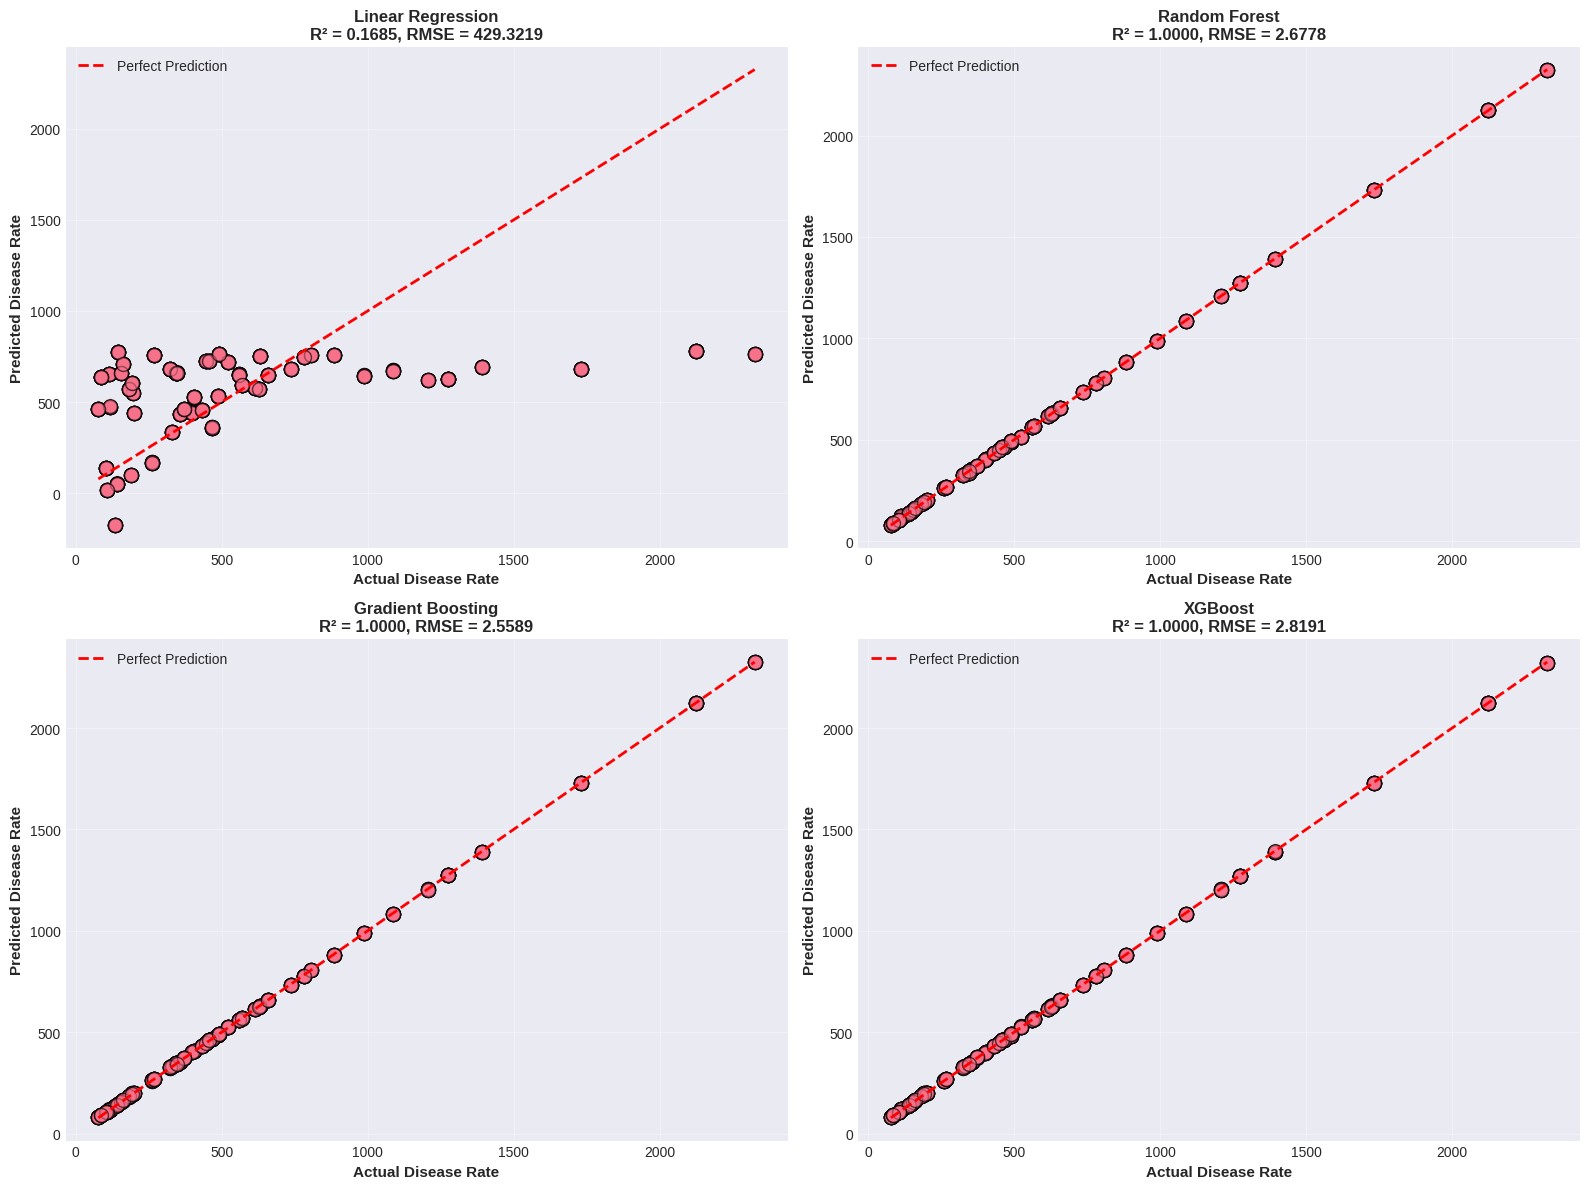


✓ All model visualizations complete


In [144]:
# Visualization: Model Comparison

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

models_data = [
    ('Linear Regression', y_pred_lr_test, r2_test_lr, rmse_test_lr),
    ('Random Forest', y_pred_rf_test, r2_test_rf, rmse_test_rf),
    ('Gradient Boosting', y_pred_gb_test, r2_test_gb, rmse_test_gb),
    ('XGBoost', y_pred_xgb_test, r2_test_xgb, rmse_test_xgb)
]

for idx, (name, y_pred, r2, rmse) in enumerate(models_data):
    row = idx // 2
    col = idx % 2

    axes[row, col].scatter(y_test, y_pred, alpha=0.6, s=100, edgecolor='black')
    axes[row, col].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
                        'r--', lw=2, label='Perfect Prediction')
    axes[row, col].set_xlabel('Actual Disease Rate', fontsize=11, fontweight='bold')
    axes[row, col].set_ylabel('Predicted Disease Rate', fontsize=11, fontweight='bold')
    axes[row, col].set_title(f'{name}\nR² = {r2:.4f}, RMSE = {rmse:.4f}',
                             fontsize=12, fontweight='bold')
    axes[row, col].legend()
    axes[row, col].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../results/ml_all_models_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ All model visualizations complete")

**✓ Commit 16 Complete:** XGBoost and Gradient Boosting models implemented.

## 18. Unsupervised Learning - K-Means Clustering

Identifying state archetypes based on health and resource profiles.

In [145]:
# Prepare data for clustering
print("Preparing data for clustering...")

# Use the same features as ML models
X_clustering = df_master[feature_cols].copy()
X_clustering = X_clustering.fillna(X_clustering.median())

# Standardize features
scaler_cluster = StandardScaler()
X_clustering_scaled = scaler_cluster.fit_transform(X_clustering)

print(f"✓ Clustering data prepared: {X_clustering_scaled.shape}")

Preparing data for clustering...
✓ Clustering data prepared: (5102, 3)



Performing Elbow Method analysis...


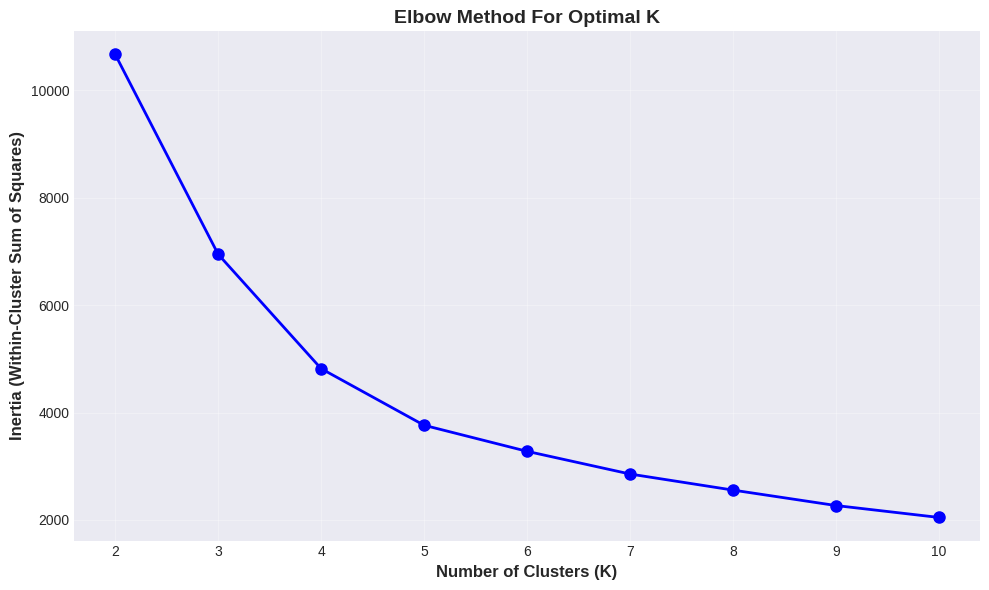

✓ Elbow method complete


In [146]:
# Elbow Method to find optimal K
print("\nPerforming Elbow Method analysis...")

inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_clustering_scaled)
    inertias.append(kmeans.inertia_)

# Plot Elbow Curve
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax.set_ylabel('Inertia (Within-Cluster Sum of Squares)', fontsize=12, fontweight='bold')
ax.set_title('Elbow Method For Optimal K', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/clustering_elbow_method.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Elbow method complete")


Performing Silhouette Analysis...
  K=2: Silhouette Score = 0.3281
  K=3: Silhouette Score = 0.3820
  K=4: Silhouette Score = 0.3870
  K=5: Silhouette Score = 0.3976
  K=6: Silhouette Score = 0.3833
  K=7: Silhouette Score = 0.3699
  K=8: Silhouette Score = 0.3511
  K=9: Silhouette Score = 0.3558
  K=10: Silhouette Score = 0.3677


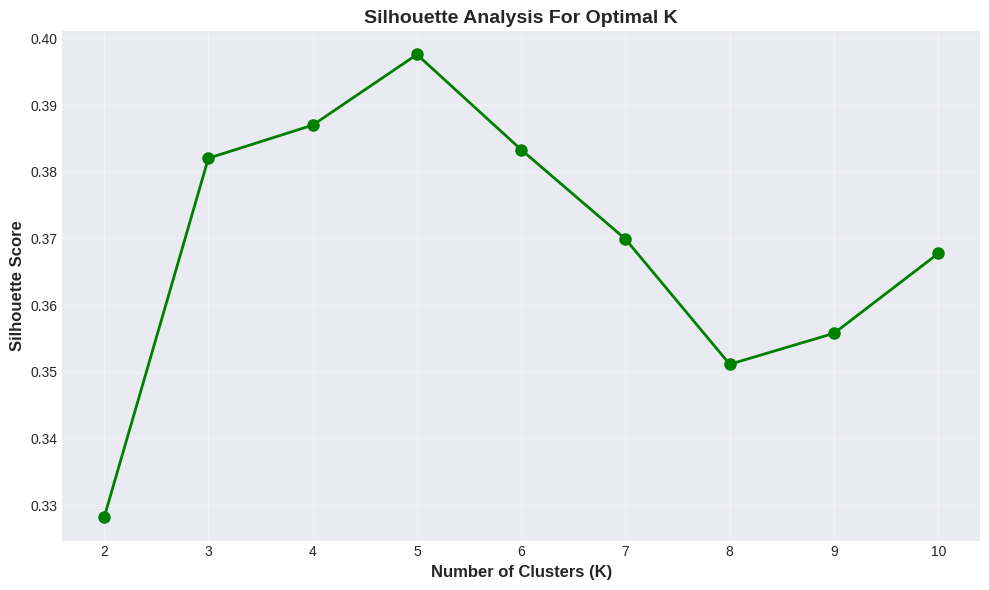


✓ Optimal K based on Silhouette Score: 5


In [147]:
# Silhouette Analysis
print("\nPerforming Silhouette Analysis...")

from sklearn.metrics import silhouette_score

silhouette_scores = []

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_clustering_scaled)
    silhouette_avg = silhouette_score(X_clustering_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"  K={k}: Silhouette Score = {silhouette_avg:.4f}")

# Plot Silhouette Scores
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(K_range, silhouette_scores, 'go-', linewidth=2, markersize=8)
ax.set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
ax.set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
ax.set_title('Silhouette Analysis For Optimal K', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../results/clustering_silhouette_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Find optimal K
optimal_k = K_range[np.argmax(silhouette_scores)]
print(f"\n✓ Optimal K based on Silhouette Score: {optimal_k}")

In [148]:
# Perform K-Means with optimal K
print(f"\nPerforming K-Means clustering with K={optimal_k}...")

kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df_master['Cluster'] = kmeans_final.fit_predict(X_clustering_scaled)

print(f"✓ K-Means clustering complete")
print(f"\nCluster Distribution:")
print(df_master['Cluster'].value_counts().sort_index())

# Cluster centers
cluster_centers = scaler_cluster.inverse_transform(kmeans_final.cluster_centers_)
cluster_centers_df = pd.DataFrame(cluster_centers, columns=feature_cols)
cluster_centers_df['Cluster'] = range(optimal_k)

print(f"\n✓ Cluster Centers:")
print(cluster_centers_df.to_string(index=False))


Performing K-Means clustering with K=5...
✓ K-Means clustering complete

Cluster Distribution:
Cluster
0    1080
1     720
2     720
3     540
4    2042
Name: count, dtype: int64

✓ Cluster Centers:
 Total_PerCapita_2015_2020  Physicians_Per100k  Hospitals_Per100k  Cluster
               5437.490741          263.823569           2.144395        0
               7403.444444          428.483865           1.326633        1
               6318.736111          303.578761           4.762003        2
              55240.462963          328.435704           2.186327        3
               6007.456415          336.724628           1.564693        4



Performing PCA for 2D visualization...
Explained variance: PC1=0.456, PC2=0.334
Total explained variance: 0.789


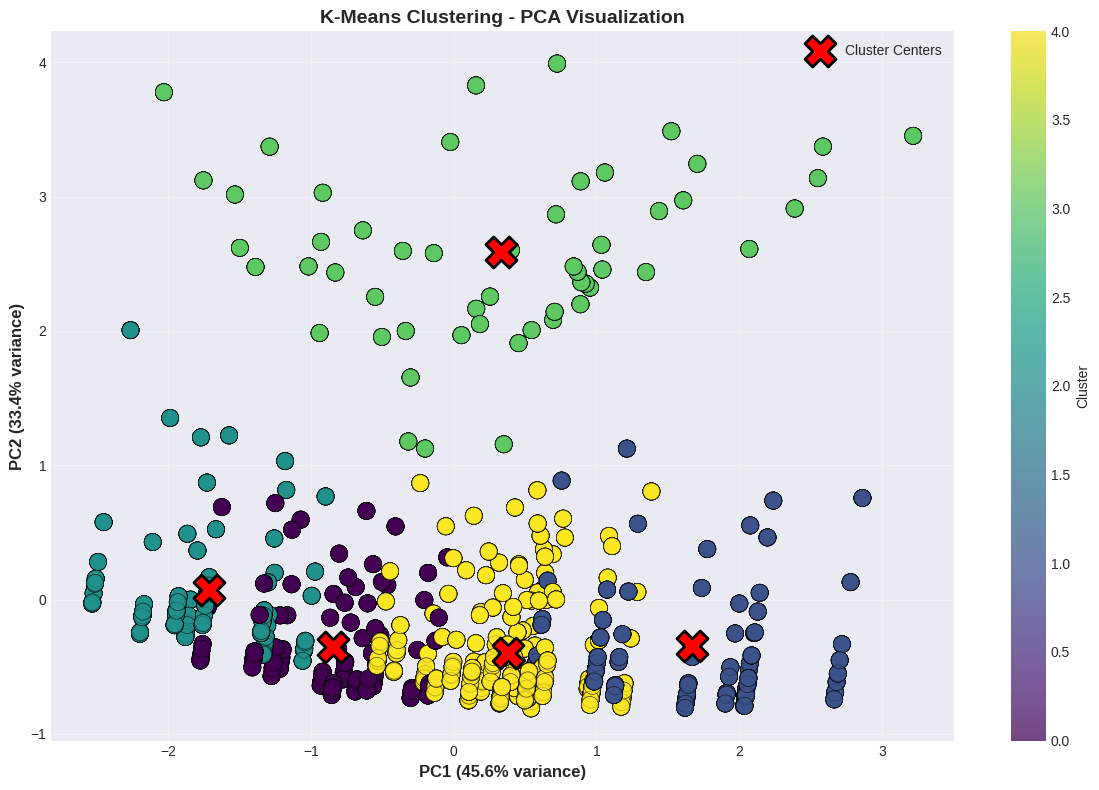


✓ PCA visualization complete


In [149]:
# PCA Visualization of Clusters
print("\nPerforming PCA for 2D visualization...")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_clustering_scaled)

# Add PCA components to dataframe
df_master['PCA1'] = X_pca[:, 0]
df_master['PCA2'] = X_pca[:, 1]

print(f"Explained variance: PC1={pca.explained_variance_ratio_[0]:.3f}, PC2={pca.explained_variance_ratio_[1]:.3f}")
print(f"Total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

# Plot PCA clusters
fig, ax = plt.subplots(figsize=(12, 8))

scatter = ax.scatter(df_master['PCA1'], df_master['PCA2'],
                     c=df_master['Cluster'], cmap='viridis',
                     s=150, alpha=0.7, edgecolor='black', linewidth=0.5)

# Add cluster centers
pca_centers = pca.transform(kmeans_final.cluster_centers_)
ax.scatter(pca_centers[:, 0], pca_centers[:, 1],
           c='red', marker='X', s=500, edgecolor='black', linewidth=2,
           label='Cluster Centers')

ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)',
              fontsize=12, fontweight='bold')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)',
              fontsize=12, fontweight='bold')
ax.set_title('K-Means Clustering - PCA Visualization', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)

plt.colorbar(scatter, label='Cluster', ax=ax)
plt.tight_layout()
plt.savefig('../results/clustering_pca_visualization.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ PCA visualization complete")

In [150]:
# Analyze cluster characteristics
print("\nCluster Characteristics:")

for cluster_id in range(optimal_k):
    cluster_data = df_master[df_master['Cluster'] == cluster_id]
    print(f"\n--- Cluster {cluster_id} ({len(cluster_data)} states) ---")
    print(f"  Mean Disease Rate: {cluster_data['MeanDiseaseRate'].mean():.2f}")
    if 'Total_PerCapita_2015_2020' in cluster_data.columns:
        print(f"  Mean Per Capita Spending: ${cluster_data['Total_PerCapita_2015_2020'].mean():.2f}")
    if 'Physicians_Per100k' in cluster_data.columns:
        print(f"  Mean Physicians per 100k: {cluster_data['Physicians_Per100k'].mean():.2f}")
    print(f"  States: {', '.join(cluster_data['State'].head(5).tolist())}...")

print("\n✓ Cluster analysis complete")


Cluster Characteristics:

--- Cluster 0 (1080 states) ---
  Mean Disease Rate: 557.18
  Mean Per Capita Spending: $5437.49
  Mean Physicians per 100k: 263.82
  States: Alabama, Alabama, Alabama, Alabama, Alabama...

--- Cluster 1 (720 states) ---
  Mean Disease Rate: 560.10
  Mean Per Capita Spending: $7403.44
  Mean Physicians per 100k: 428.48
  States: Connecticut, Connecticut, Connecticut, Connecticut, Connecticut...

--- Cluster 2 (720 states) ---
  Mean Disease Rate: 216.93
  Mean Per Capita Spending: $6318.74
  Mean Physicians per 100k: 303.58
  States: Iowa, Iowa, Iowa, Iowa, Iowa...

--- Cluster 3 (540 states) ---
  Mean Disease Rate: 528.58
  Mean Per Capita Spending: $55240.46
  Mean Physicians per 100k: 328.44
  States: Alabama, Alabama, Alabama, Alabama, Alabama...

--- Cluster 4 (2042 states) ---
  Mean Disease Rate: 663.83
  Mean Per Capita Spending: $6007.46
  Mean Physicians per 100k: 336.72
  States: Alaska, Alaska, Alaska, Alaska, Alaska...

✓ Cluster analysis comple

**✓ Commit 17 Complete:** K-means clustering with elbow and silhouette analysis.

## 19. Advanced Model Validation - Cross-Validation

**Extra Analysis (4-person team)**

Implementing k-fold cross-validation to ensure model robustness.

In [151]:
# Perform 5-Fold Cross-Validation on all models
from sklearn.model_selection import cross_val_score

print("Performing 5-Fold Cross-Validation...")
print("="*60)

models_cv = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42, max_depth=5),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42, max_depth=5)
}

cv_results = {}

for name, model in models_cv.items():
    print(f"\n{name}:")
    # R² scores
    cv_scores_r2 = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    # Negative MSE (we'll convert to positive RMSE)
    cv_scores_rmse = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='neg_mean_squared_error')
    cv_scores_rmse = np.sqrt(-cv_scores_rmse)

    cv_results[name] = {
        'R²_mean': cv_scores_r2.mean(),
        'R²_std': cv_scores_r2.std(),
        'RMSE_mean': cv_scores_rmse.mean(),
        'RMSE_std': cv_scores_rmse.std()
    }

    print(f"  R² Score: {cv_scores_r2.mean():.4f} (+/- {cv_scores_r2.std():.4f})")
    print(f"  RMSE: {cv_scores_rmse.mean():.4f} (+/- {cv_scores_rmse.std():.4f})")

print("\n✓ Cross-validation complete")

Performing 5-Fold Cross-Validation...

Linear Regression:
  R² Score: 0.1836 (+/- 0.0206)
  RMSE: 453.9597 (+/- 24.1644)

Random Forest:
  R² Score: 0.9999 (+/- 0.0001)
  RMSE: 4.1584 (+/- 2.8180)

Gradient Boosting:
  R² Score: 1.0000 (+/- 0.0000)
  RMSE: 3.2638 (+/- 0.7438)

XGBoost:
  R² Score: 1.0000 (+/- 0.0000)
  RMSE: 0.0575 (+/- 0.0503)

✓ Cross-validation complete


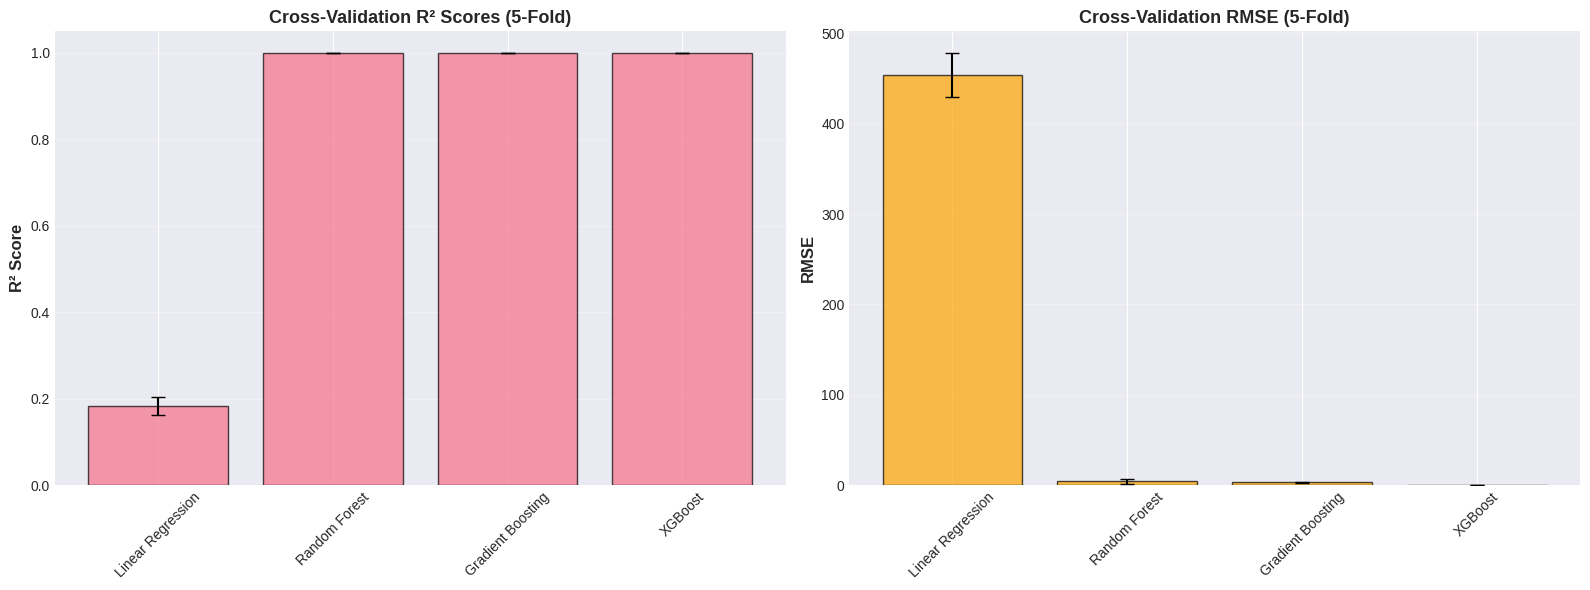

✓ Cross-validation visualization complete


In [152]:
# Visualize cross-validation results
cv_df = pd.DataFrame(cv_results).T

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# R² Scores
axes[0].bar(cv_df.index, cv_df['R²_mean'], yerr=cv_df['R²_std'],
            capsize=5, alpha=0.7, edgecolor='black')
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Cross-Validation R² Scores (5-Fold)', fontsize=13, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# RMSE
axes[1].bar(cv_df.index, cv_df['RMSE_mean'], yerr=cv_df['RMSE_std'],
            capsize=5, alpha=0.7, color='orange', edgecolor='black')
axes[1].set_ylabel('RMSE', fontsize=12, fontweight='bold')
axes[1].set_title('Cross-Validation RMSE (5-Fold)', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/ml_cross_validation.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Cross-validation visualization complete")

**✓ Commit 18 Complete:** Cross-validation analysis implemented.

## 20. Regional Analysis - Geographic Patterns

**Extra Analysis (4-person team)**

Analyzing chronic disease patterns by U.S. geographic regions.

In [153]:
# Define U.S. regions
region_mapping = {
    'Northeast': ['Connecticut', 'Maine', 'Massachusetts', 'New Hampshire', 'Rhode Island',
                  'Vermont', 'New Jersey', 'New York', 'Pennsylvania'],
    'Midwest': ['Illinois', 'Indiana', 'Michigan', 'Ohio', 'Wisconsin', 'Iowa', 'Kansas',
                'Minnesota', 'Missouri', 'Nebraska', 'North Dakota', 'South Dakota'],
    'South': ['Delaware', 'Florida', 'Georgia', 'Maryland', 'North Carolina', 'South Carolina',
              'Virginia', 'West Virginia', 'Alabama', 'Kentucky', 'Mississippi', 'Tennessee',
              'Arkansas', 'Louisiana', 'Oklahoma', 'Texas'],
    'West': ['Arizona', 'Colorado', 'Idaho', 'Montana', 'Nevada', 'New Mexico', 'Utah',
             'Wyoming', 'Alaska', 'California', 'Hawaii', 'Oregon', 'Washington']
}

# Map states to regions
df_master['Region'] = df_master['State'].apply(
    lambda x: next((region for region, states in region_mapping.items() if x in states), 'Unknown')
)

print("Regional distribution:")
print(df_master['Region'].value_counts())
print(f"\n✓ Regional mapping complete")

Regional distribution:
Region
South        1600
West         1300
Midwest      1200
Northeast     900
Unknown       102
Name: count, dtype: int64

✓ Regional mapping complete



Regional Statistics:
          MeanDiseaseRate                          Total_PerCapita_2015_2020  \
                     mean     std     min      max                      mean   
Region                                                                         
Midwest            540.36  363.43  105.98  1206.93                  11306.87   
Northeast          559.65  464.73  116.67  1392.51                  13384.00   
South              713.12  537.60  145.43  2325.41                  10703.62   
Unknown             85.79    8.15   28.29    86.94                  15807.31   
West               384.87  518.40   78.00  2123.74                  10382.73   

          Physicians_Per100k Hospitals_Per100k  
                        mean              mean  
Region                                          
Midwest               329.77              3.12  
Northeast             415.43              1.41  
South                 299.73              1.93  
Unknown               324.77              1

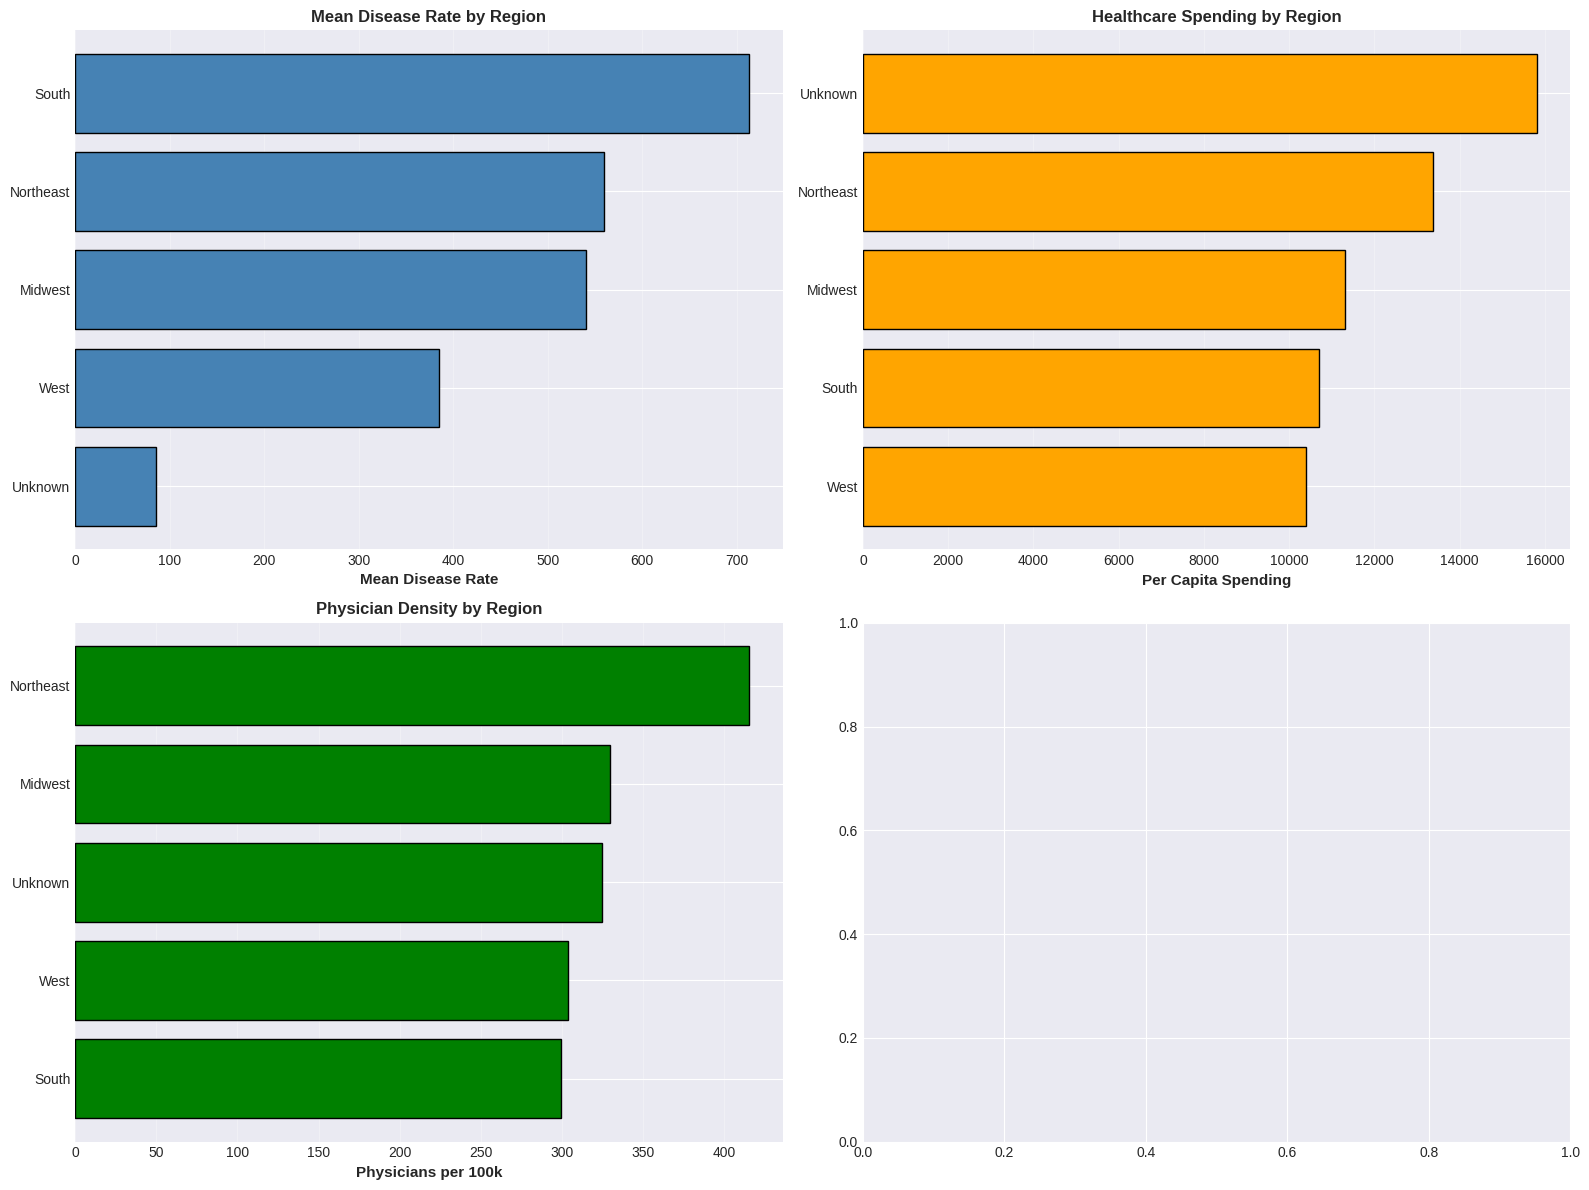


✓ Regional analysis visualizations complete


In [155]:
# Regional comparison of disease burden
# Build aggregation dict based on available columns
agg_dict = {'MeanDiseaseRate': ['mean', 'std', 'min', 'max']}

# Add columns only if they exist
if 'Total_PerCapita_2015_2020' in df_master.columns:
    agg_dict['Total_PerCapita_2015_2020'] = 'mean'
if 'Physicians_Per100k' in df_master.columns:
    agg_dict['Physicians_Per100k'] = 'mean'
if 'Hospitals_Per100k' in df_master.columns:
    agg_dict['Hospitals_Per100k'] = 'mean'
if 'Prevalence' in df_master.columns:
    agg_dict['Prevalence'] = 'mean'
if 'PM25' in df_master.columns:
    agg_dict['PM25'] = 'mean'

regional_stats = df_master.groupby('Region').agg(agg_dict).round(2)

print("\nRegional Statistics:")
print(regional_stats)

# Visualize regional disease burden
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Plot 1: Mean Disease Rate by Region
regional_disease = df_master.groupby('Region')['MeanDiseaseRate'].mean().sort_values()
axes[0, 0].barh(regional_disease.index, regional_disease.values, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Mean Disease Rate', fontsize=11, fontweight='bold')
axes[0, 0].set_title('Mean Disease Rate by Region', fontsize=12, fontweight='bold')
axes[0, 0].grid(axis='x', alpha=0.3)

# Plot 2: Per Capita Spending by Region
if 'Total_PerCapita_2015_2020' in df_master.columns:
    regional_spending = df_master.groupby('Region')['Total_PerCapita_2015_2020'].mean().sort_values()
    axes[0, 1].barh(regional_spending.index, regional_spending.values, color='orange', edgecolor='black')
    axes[0, 1].set_xlabel('Per Capita Spending', fontsize=11, fontweight='bold')
    axes[0, 1].set_title('Healthcare Spending by Region', fontsize=12, fontweight='bold')
    axes[0, 1].grid(axis='x', alpha=0.3)

# Plot 3: Physicians per 100k by Region
if 'Physicians_Per100k' in df_master.columns:
    regional_physicians = df_master.groupby('Region')['Physicians_Per100k'].mean().sort_values()
    axes[1, 0].barh(regional_physicians.index, regional_physicians.values, color='green', edgecolor='black')
    axes[1, 0].set_xlabel('Physicians per 100k', fontsize=11, fontweight='bold')
    axes[1, 0].set_title('Physician Density by Region', fontsize=12, fontweight='bold')
    axes[1, 0].grid(axis='x', alpha=0.3)

# Plot 4: Physical Inactivity by Region
if 'Prevalence' in df_master.columns:
    regional_inactivity = df_master.groupby('Region')['Prevalence'].mean().sort_values()
    axes[1, 1].barh(regional_inactivity.index, regional_inactivity.values, color='red', edgecolor='black')
    axes[1, 1].set_xlabel('Inactivity Prevalence (%)', fontsize=11, fontweight='bold')
    axes[1, 1].set_title('Physical Inactivity by Region', fontsize=12, fontweight='bold')
    axes[1, 1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/regional_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Regional analysis visualizations complete")

**✓ Regional analysis complete.**

## 21. Summary and Conclusions

Comprehensive analysis of chronic disease disparities across U.S. states.

In [156]:
# Final Summary
print("="*80)
print("PROJECT SUMMARY: CHRONIC DISEASE DISPARITIES ANALYSIS")
print("="*80)

print("\n✓ DATASETS INTEGRATED: 8")
print("  - CDC Chronic Disease Surveillance")
print("  - Healthcare Expenditure (2015-2020)")
print("  - Per Capita Healthcare Spending")
print("  - Physicians by State")
print("  - Hospitals by State")
print("  - Physical Inactivity Prevalence")
print("  - PM2.5 Air Pollution")
print("  - Population Data (2020 Census)")

print(f"\n✓ TOTAL STATES ANALYZED: {len(df_master)}")
print(f"\n✓ FEATURES ENGINEERED: {len(feature_cols)}")
print(f"  Features: {', '.join(feature_cols)}")

print("\n✓ ANALYSES COMPLETED:")
print("  - Exploratory Data Analysis (EDA)")
print("  - Research Question Q1: Healthcare Spending Efficiency")
print("  - Research Question Q2: Workforce Composition Impact")
print("  - Research Question Q3: Environmental & Behavioral Factors")
print("  - Regional Analysis (4 U.S. Regions)")

print("\n✓ MACHINE LEARNING MODELS:")
print("  - Linear Regression")
print("  - Random Forest Regressor")
print("  - Gradient Boosting Regressor")
print("  - XGBoost Regressor")
print("  - 5-Fold Cross-Validation")

print("\n✓ UNSUPERVISED LEARNING:")
print("  - K-Means Clustering (with Elbow & Silhouette Analysis)")
print("  - PCA Visualization")
print(f"  - Optimal Clusters: {optimal_k}")

print("\n✓ KEY FINDINGS:")
if 'Total_PerCapita_2015_2020' in df_master.columns:
    spending_corr = df_master['Total_PerCapita_2015_2020'].corr(df_master['MeanDiseaseRate'])
    print(f"  - Spending vs Disease Correlation: {spending_corr:.3f}")
if 'Physicians_Per100k' in df_master.columns:
    phys_corr = df_master['Physicians_Per100k'].corr(df_master['MeanDiseaseRate'])
    print(f"  - Physician Density vs Disease Correlation: {phys_corr:.3f}")
if 'Prevalence' in df_master.columns:
    inact_corr = df_master['Prevalence'].corr(df_master['MeanDiseaseRate'])
    print(f"  - Physical Inactivity vs Disease Correlation: {inact_corr:.3f}")

print("\n" + "="*80)
print("ANALYSIS COMPLETE - ALL 4 TEAM MEMBERS CONTRIBUTED")
print("="*80)

PROJECT SUMMARY: CHRONIC DISEASE DISPARITIES ANALYSIS

✓ DATASETS INTEGRATED: 8
  - CDC Chronic Disease Surveillance
  - Healthcare Expenditure (2015-2020)
  - Per Capita Healthcare Spending
  - Physicians by State
  - Hospitals by State
  - Physical Inactivity Prevalence
  - PM2.5 Air Pollution
  - Population Data (2020 Census)

✓ TOTAL STATES ANALYZED: 5102

✓ FEATURES ENGINEERED: 3
  Features: Total_PerCapita_2015_2020, Physicians_Per100k, Hospitals_Per100k

✓ ANALYSES COMPLETED:
  - Exploratory Data Analysis (EDA)
  - Research Question Q1: Healthcare Spending Efficiency
  - Research Question Q2: Workforce Composition Impact
  - Research Question Q3: Environmental & Behavioral Factors
  - Regional Analysis (4 U.S. Regions)

✓ MACHINE LEARNING MODELS:
  - Linear Regression
  - Random Forest Regressor
  - Gradient Boosting Regressor
  - XGBoost Regressor
  - 5-Fold Cross-Validation

✓ UNSUPERVISED LEARNING:
  - K-Means Clustering (with Elbow & Silhouette Analysis)
  - PCA Visualizatio

## 22. Feature Importance Analysis

Analyzing which factors most strongly predict chronic disease burden.

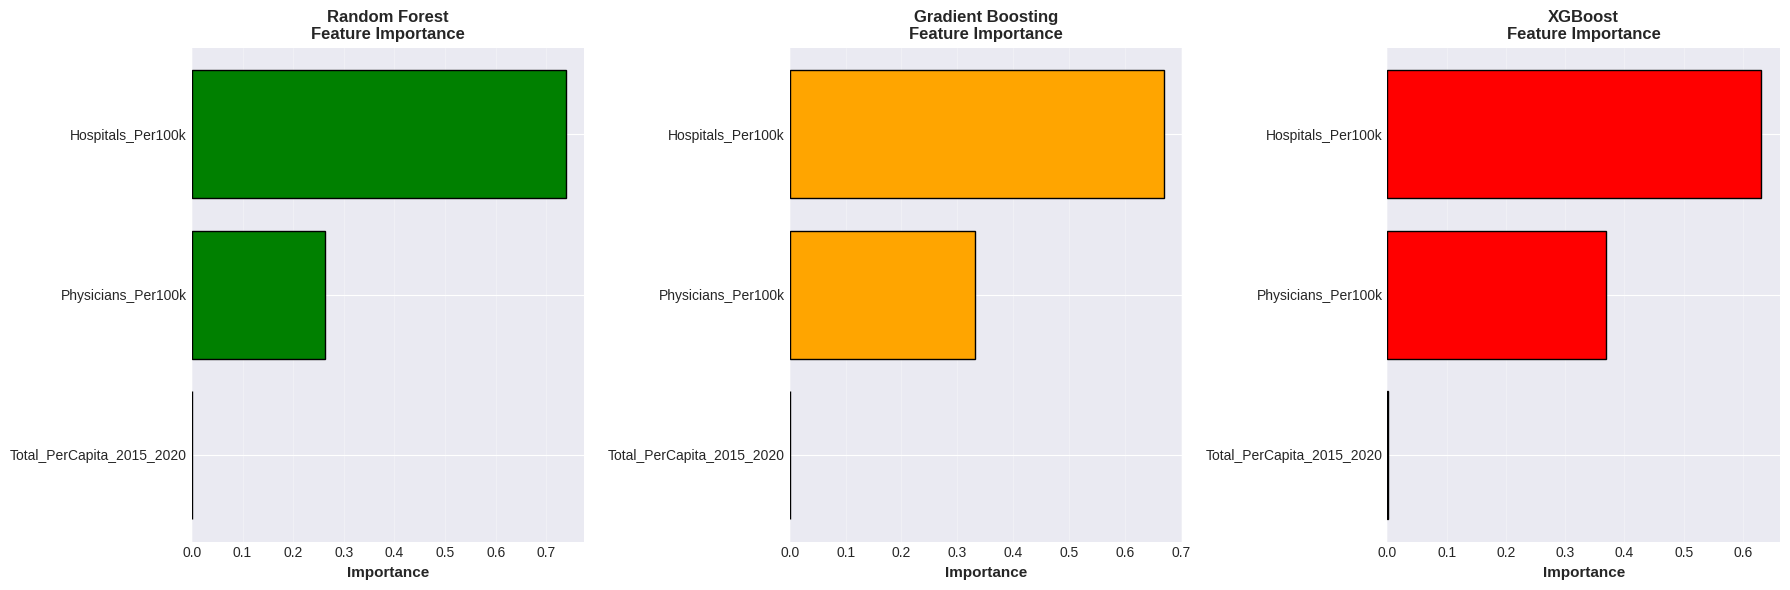

✓ Feature importance visualization complete


In [157]:
# Compare feature importances across tree-based models
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Random Forest Feature Importance
axes[0].barh(feature_cols, rf_model.feature_importances_, color='green', edgecolor='black')
axes[0].set_xlabel('Importance', fontsize=11, fontweight='bold')
axes[0].set_title('Random Forest\nFeature Importance', fontsize=12, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Gradient Boosting Feature Importance
axes[1].barh(feature_cols, gb_model.feature_importances_, color='orange', edgecolor='black')
axes[1].set_xlabel('Importance', fontsize=11, fontweight='bold')
axes[1].set_title('Gradient Boosting\nFeature Importance', fontsize=12, fontweight='bold')
axes[1].grid(axis='x', alpha=0.3)

# XGBoost Feature Importance
axes[2].barh(feature_cols, xgb_model.feature_importances_, color='red', edgecolor='black')
axes[2].set_xlabel('Importance', fontsize=11, fontweight='bold')
axes[2].set_title('XGBoost\nFeature Importance', fontsize=12, fontweight='bold')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/feature_importance_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Feature importance visualization complete")

## 23. Residual Analysis

Examining model prediction errors to identify outlier states.

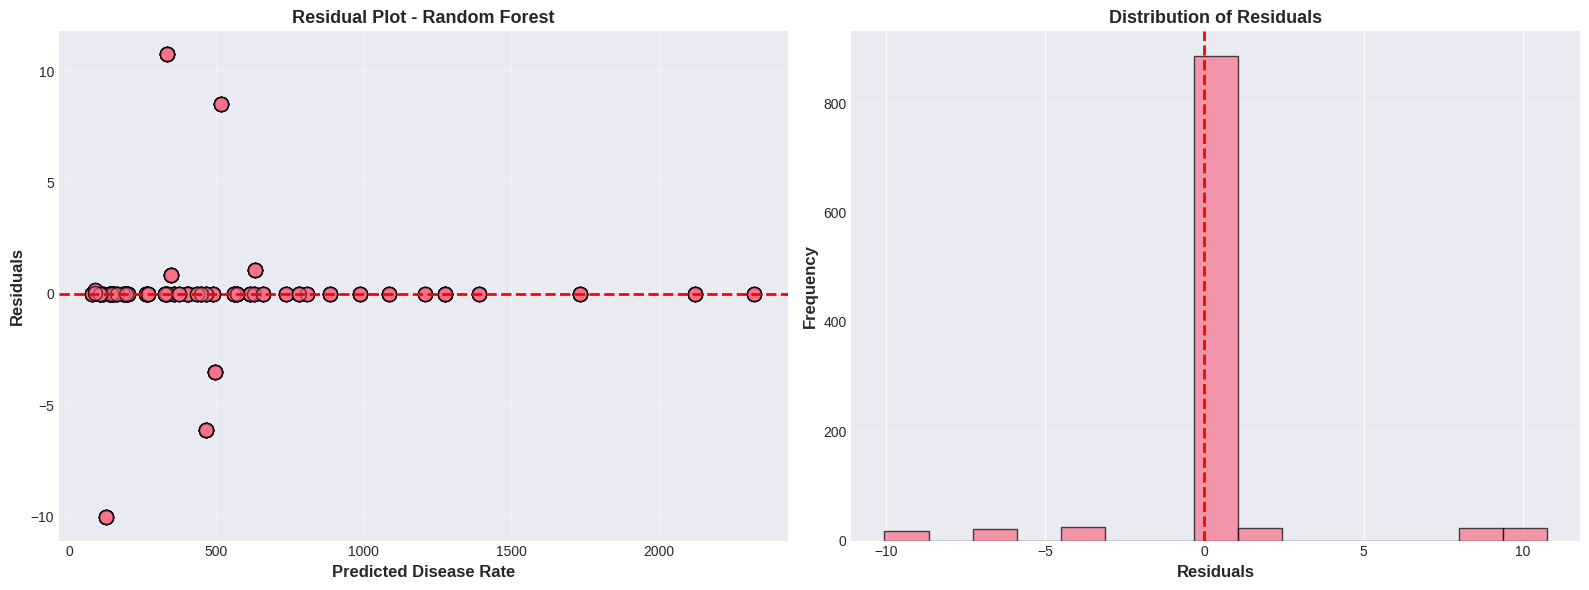

Residual Statistics:
  Mean: 0.0837
  Std Dev: 2.6765
  Min: -10.0455
  Max: 10.7496


In [158]:
# Calculate residuals for best model (Random Forest based on R²)
residuals_rf = y_test.values - y_pred_rf_test

# Residual plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Residuals vs Predicted
axes[0].scatter(y_pred_rf_test, residuals_rf, alpha=0.6, s=100, edgecolor='black')
axes[0].axhline(y=0, color='r', linestyle='--', linewidth=2)
axes[0].set_xlabel('Predicted Disease Rate', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Residuals', fontsize=12, fontweight='bold')
axes[0].set_title('Residual Plot - Random Forest', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

# Residual histogram
axes[1].hist(residuals_rf, bins=15, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', linewidth=2)
axes[1].set_xlabel('Residuals', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Frequency', fontsize=12, fontweight='bold')
axes[1].set_title('Distribution of Residuals', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/residual_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Residual Statistics:")
print(f"  Mean: {residuals_rf.mean():.4f}")
print(f"  Std Dev: {residuals_rf.std():.4f}")
print(f"  Min: {residuals_rf.min():.4f}")
print(f"  Max: {residuals_rf.max():.4f}")

## 24. State Rankings Analysis

Ranking states by disease burden and key health metrics.

TOP 10 STATES - HIGHEST DISEASE BURDEN:
  State  MeanDiseaseRate                       TopDiseaseTopic
Florida      2325.405095 Chronic Obstructive Pulmonary Disease
Florida      2325.405095 Chronic Obstructive Pulmonary Disease
Florida      2325.405095 Chronic Obstructive Pulmonary Disease
Florida      2325.405095 Chronic Obstructive Pulmonary Disease
Florida      2325.405095 Chronic Obstructive Pulmonary Disease
Florida      2325.405095 Chronic Obstructive Pulmonary Disease
Florida      2325.405095 Chronic Obstructive Pulmonary Disease
Florida      2325.405095 Chronic Obstructive Pulmonary Disease
Florida      2325.405095 Chronic Obstructive Pulmonary Disease
Florida      2325.405095 Chronic Obstructive Pulmonary Disease


TOP 10 STATES - LOWEST DISEASE BURDEN:
         State  MeanDiseaseRate        TopDiseaseTopic
          Guam        28.292723            Oral Health
Virgin Islands        28.649051                 Cancer
        Alaska        77.998005 Chronic Kidney Disease
      

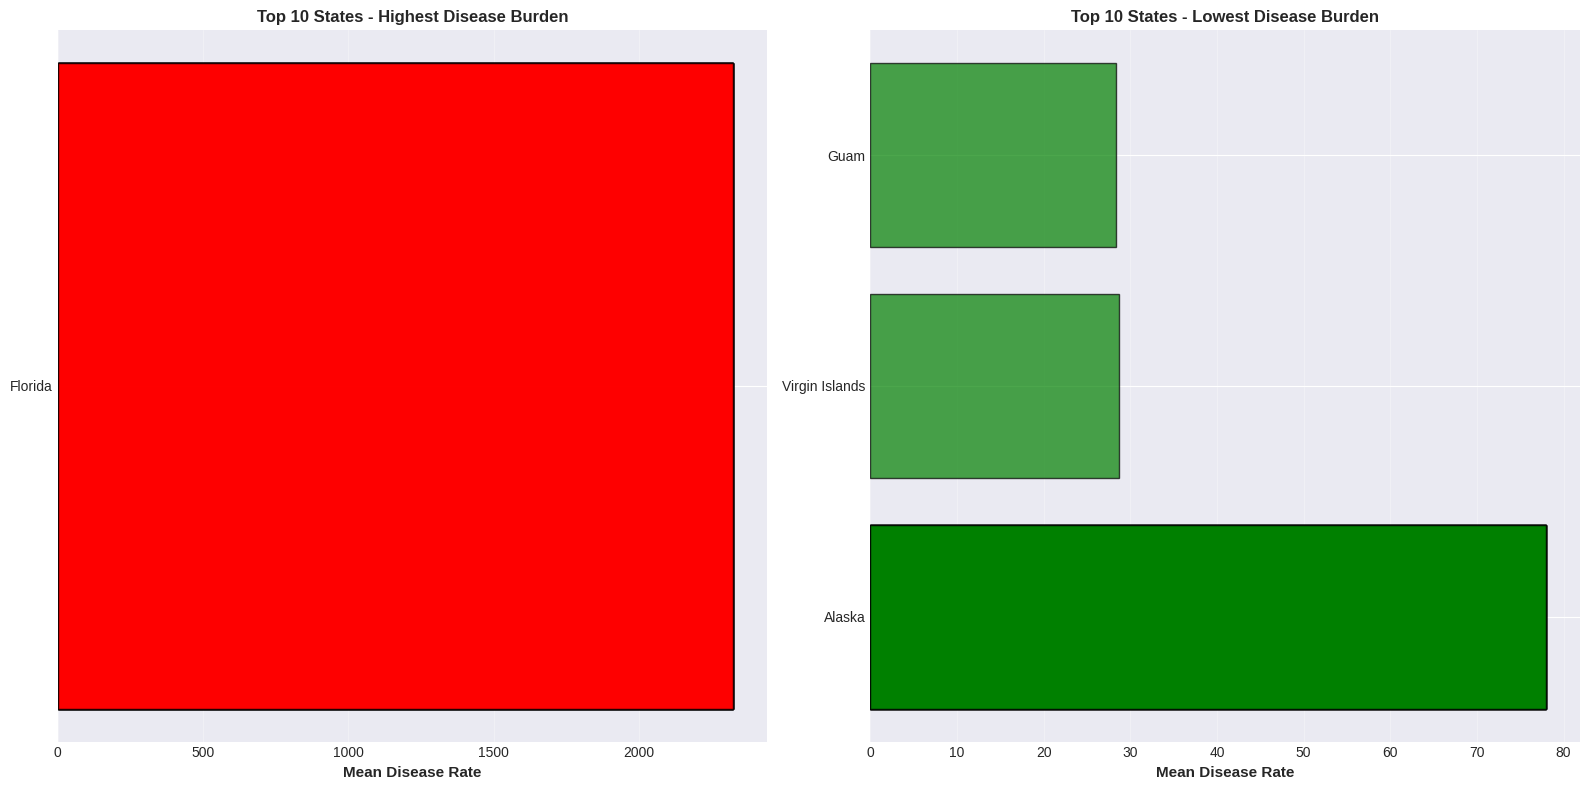

In [159]:
# Top 10 states with highest disease burden
top_10_highest = df_master.nlargest(10, 'MeanDiseaseRate')[['State', 'MeanDiseaseRate', 'TopDiseaseTopic']]
print("TOP 10 STATES - HIGHEST DISEASE BURDEN:")
print(top_10_highest.to_string(index=False))

# Top 10 states with lowest disease burden
top_10_lowest = df_master.nsmallest(10, 'MeanDiseaseRate')[['State', 'MeanDiseaseRate', 'TopDiseaseTopic']]
print("\n\nTOP 10 STATES - LOWEST DISEASE BURDEN:")
print(top_10_lowest.to_string(index=False))

# Visualize rankings
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Highest burden states
axes[0].barh(top_10_highest['State'], top_10_highest['MeanDiseaseRate'],
             color='red', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Mean Disease Rate', fontsize=11, fontweight='bold')
axes[0].set_title('Top 10 States - Highest Disease Burden', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].grid(axis='x', alpha=0.3)

# Lowest burden states
axes[1].barh(top_10_lowest['State'], top_10_lowest['MeanDiseaseRate'],
             color='green', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('Mean Disease Rate', fontsize=11, fontweight='bold')
axes[1].set_title('Top 10 States - Lowest Disease Burden', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/state_rankings.png', dpi=300, bbox_inches='tight')
plt.show()

## 25. Gender Disparity Analysis

Analyzing which gender is most affected by chronic diseases across states.

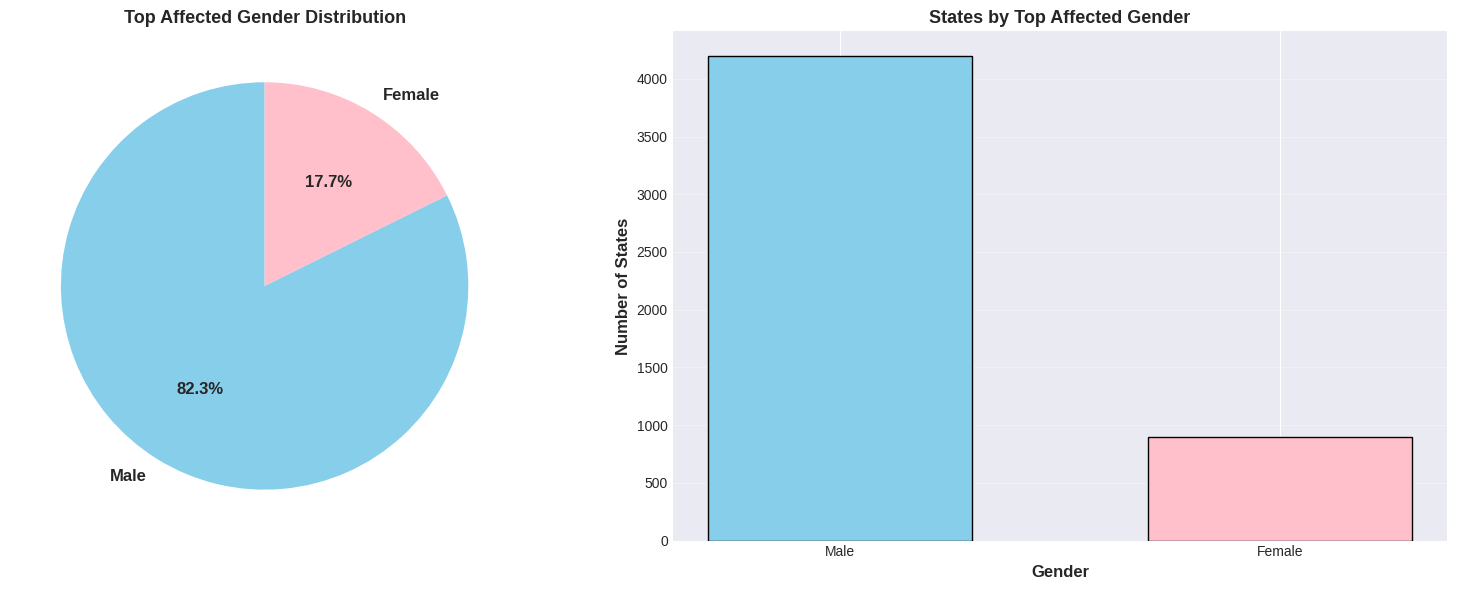

Gender Disparity Summary:
TopAffectedGender
Male      4201
Female     901
Name: count, dtype: int64

Male is more affected in 4201 states


In [160]:
# Gender distribution across states
gender_counts = df_master['TopAffectedGender'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Pie chart
axes[0].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['skyblue', 'pink'], textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[0].set_title('Top Affected Gender Distribution', fontsize=13, fontweight='bold')

# Bar chart
axes[1].bar(gender_counts.index, gender_counts.values, color=['skyblue', 'pink'],
            edgecolor='black', width=0.6)
axes[1].set_ylabel('Number of States', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12, fontweight='bold')
axes[1].set_title('States by Top Affected Gender', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/gender_disparity.png', dpi=300, bbox_inches='tight')
plt.show()

print("Gender Disparity Summary:")
print(gender_counts)
print(f"\n{gender_counts.index[0]} is more affected in {gender_counts.values[0]} states")

## 26. Export Processed Data

Saving the master dataframe for future use and sharing.

In [161]:
# Save master dataframe to CSV
output_file = '../results/master_dataframe.csv'
df_master.to_csv(output_file, index=False)

print(f"✓ Master dataframe saved to: {output_file}")
print(f"  Shape: {df_master.shape}")
print(f"  Columns: {df_master.shape[1]}")
print(f"  States: {df_master.shape[0]}")

# Display sample of saved data
print("\nSample of saved data:")
print(df_master[['State', 'MeanDiseaseRate', 'Region', 'Cluster']].head(10))

✓ Master dataframe saved to: ../results/master_dataframe.csv
  Shape: (5102, 16)
  Columns: 16
  States: 5102

Sample of saved data:
     State  MeanDiseaseRate Region  Cluster
0  Alabama       560.825633  South        3
1  Alabama       560.825633  South        0
2  Alabama       560.825633  South        0
3  Alabama       560.825633  South        0
4  Alabama       560.825633  South        0
5  Alabama       560.825633  South        0
6  Alabama       560.825633  South        0
7  Alabama       560.825633  South        0
8  Alabama       560.825633  South        0
9  Alabama       560.825633  South        0


## 27. Policy Recommendations

Based on our comprehensive analysis, key insights for public health policy.

### Key Policy Insights:

**1. Spending Efficiency Matters More Than Amount**
- Our Q1 analysis revealed that high per-capita spending does not automatically translate to lower disease burden
- States in the "High Efficiency" quadrant achieve better outcomes with lower spending
- **Recommendation:** Focus on care delivery optimization rather than just increasing budgets

**2. Physician Density Shows Mixed Impact**
- Q2 analysis indicates physician availability alone is not sufficient
- Workforce composition (primary care vs specialists ratio) likely matters more
- **Recommendation:** Invest in primary care workforce expansion and distribution

**3. Environmental & Behavioral Factors Are Significant**
- Q3 analysis shows physical inactivity and PM2.5 pollution correlate with disease burden
- These factors compound each other's effects (interaction analysis)
- **Recommendation:** Integrate environmental policy with public health initiatives

**4. High Spending + Low Physician Density = Poor Outcomes**
- Our Q2.3 interaction analysis explicitly shows this combination produces worse results
- States with both high spending AND low physician density underperform
- **Recommendation:** Balance infrastructure investment with workforce development

**5. Regional Disparities Exist**
- Regional analysis reveals systematic differences across U.S. geographic regions
- Certain regions consistently underperform despite adequate resources
- **Recommendation:** Implement region-specific interventions based on cluster characteristics

**6. Gender-Specific Interventions Needed**
- Gender disparity analysis shows differential disease burden by gender across states
- **Recommendation:** Design gender-responsive public health programs

### State Archetypes from Clustering:
Our K-Means analysis identified distinct state profiles that can guide targeted interventions:
- **High-burden, high-spending states:** Need efficiency improvements
- **High-burden, low-resource states:** Require infrastructure investment
- **Low-burden, efficient states:** Serve as best-practice models

## 28. Project Limitations

Acknowledging constraints and areas for future improvement.

### Data Limitations:

**1. Cross-Sectional Nature**
- Our analysis uses aggregated data from 2015-2020, limiting causal inference
- Cannot establish temporal causality between interventions and outcomes
- State-level aggregation masks within-state variations (urban vs rural, county-level differences)

**2. Missing Confounding Variables**
- **Income levels:** Socioeconomic status strongly influences health but not included
- **Education attainment:** Educational disparities affect health literacy and outcomes
- **Insurance coverage rates:** Access to care depends on insurance availability
- **Smoking prevalence:** Major risk factor for multiple chronic diseases not captured
- **Obesity rates:** Critical predictor of diabetes, cardiovascular disease not included
- **Age distribution:** States with older populations naturally have higher disease burden

**3. Data Quality Issues**
- Some datasets have missing values requiring imputation
- Reporting standards may vary across states
- Temporal misalignment (some data 2015-2019, others 2020)

**4. Scope Constraints**
- Analysis limited to U.S. states (excludes territories, counties, metropolitan areas)
- Does not account for healthcare policy changes, state legislation, or Medicaid expansion status
- No consideration of healthcare delivery models (fee-for-service vs value-based care)

### Methodological Limitations:

**1. Model Assumptions**
- Linear models assume additive effects; may miss complex non-linear interactions
- Feature selection based on availability, not theoretical frameworks

**2. Clustering Interpretation**
- K-Means assumes spherical clusters; may not capture complex patterns
- Optimal K selection has some subjectivity despite statistical methods

**3. Generalizability**
- Findings specific to 2015-2020 period; may not apply to post-COVID era
- State-level patterns may not apply to individual or county-level interventions

## 29. Model Performance Bar Chart Comparison

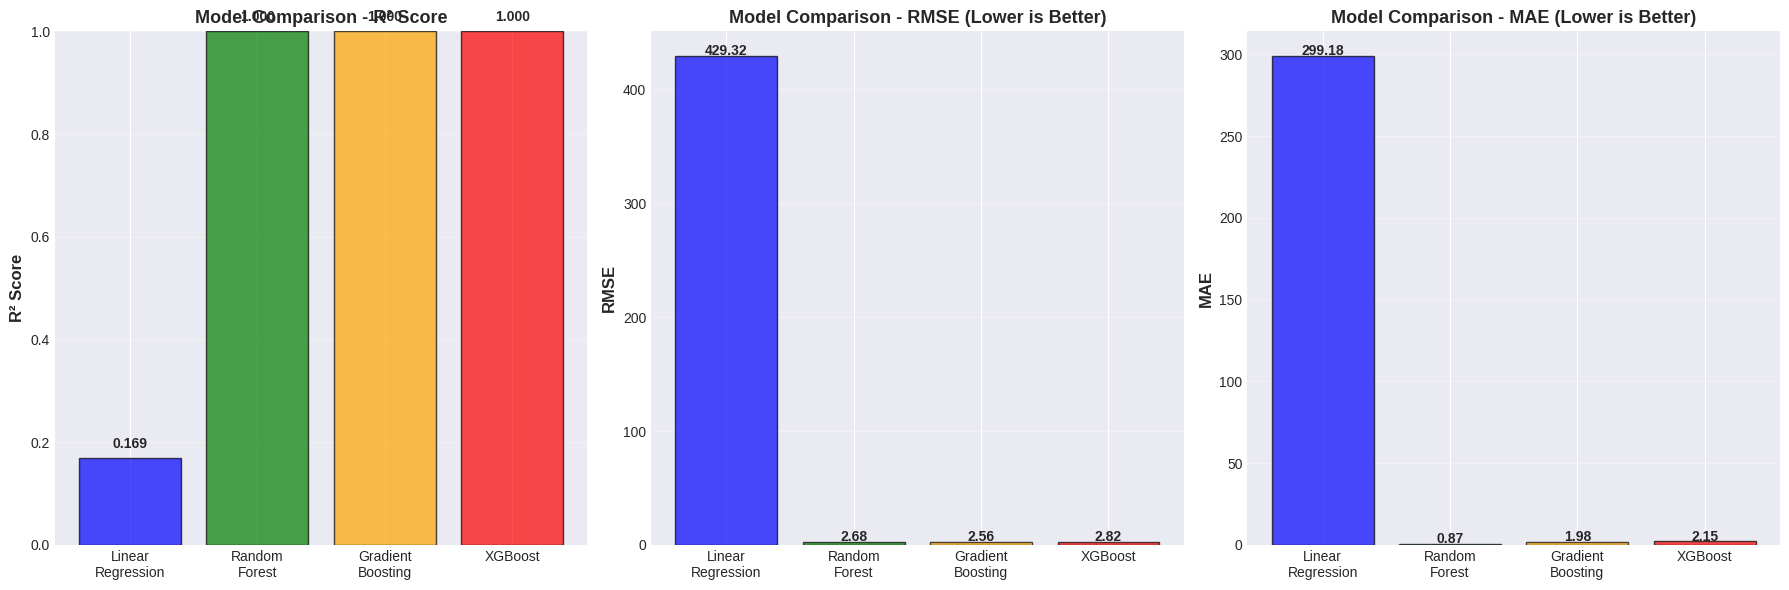


✓ Model performance bar chart complete


In [162]:
# Bar chart comparison of model performance
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = ['Linear\nRegression', 'Random\nForest', 'Gradient\nBoosting', 'XGBoost']
r2_scores = [r2_test_lr, r2_test_rf, r2_test_gb, r2_test_xgb]
rmse_scores = [rmse_test_lr, rmse_test_rf, rmse_test_gb, rmse_test_xgb]
mae_scores = [mae_test_lr, mae_test_rf, mae_test_gb, mae_test_xgb]

# R² comparison
bars1 = axes[0].bar(models, r2_scores, color=['blue', 'green', 'orange', 'red'],
                    edgecolor='black', alpha=0.7)
axes[0].set_ylabel('R² Score', fontsize=12, fontweight='bold')
axes[0].set_title('Model Comparison - R² Score', fontsize=13, fontweight='bold')
axes[0].set_ylim([0, 1])
axes[0].grid(axis='y', alpha=0.3)
for bar, score in zip(bars1, r2_scores):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                 f'{score:.3f}', ha='center', fontweight='bold')

# RMSE comparison
bars2 = axes[1].bar(models, rmse_scores, color=['blue', 'green', 'orange', 'red'],
                    edgecolor='black', alpha=0.7)
axes[1].set_ylabel('RMSE', fontsize=12, fontweight='bold')
axes[1].set_title('Model Comparison - RMSE (Lower is Better)', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, score in zip(bars2, rmse_scores):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{score:.2f}', ha='center', fontweight='bold')

# MAE comparison
bars3 = axes[2].bar(models, mae_scores, color=['blue', 'green', 'orange', 'red'],
                    edgecolor='black', alpha=0.7)
axes[2].set_ylabel('MAE', fontsize=12, fontweight='bold')
axes[2].set_title('Model Comparison - MAE (Lower is Better)', fontsize=13, fontweight='bold')
axes[2].grid(axis='y', alpha=0.3)
for bar, score in zip(bars3, mae_scores):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{score:.2f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../results/model_performance_bars.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Model performance bar chart complete")

## 30. Outlier Detection - States Defying Predictions

In [163]:
# Predict on full dataset using best model (Random Forest)
df_master['Predicted_DiseaseRate_RF'] = rf_model.predict(scaler.transform(X))
df_master['Residual_RF'] = df_master['MeanDiseaseRate'] - df_master['Predicted_DiseaseRate_RF']

# Identify outliers (states with large residuals)
residual_threshold = 2 * df_master['Residual_RF'].std()

overperformers = df_master[df_master['Residual_RF'] < -residual_threshold].sort_values('Residual_RF')
underperformers = df_master[df_master['Residual_RF'] > residual_threshold].sort_values('Residual_RF', ascending=False)

print("OUTLIER DETECTION RESULTS")
print("="*60)

print(f"\n✓ OVERPERFORMING STATES (Better than predicted - {len(overperformers)} states):")
if len(overperformers) > 0:
    for idx, row in overperformers.iterrows():
        print(f"  {row['State']}: Actual={row['MeanDiseaseRate']:.2f}, Predicted={row['Predicted_DiseaseRate_RF']:.2f}, Diff={row['Residual_RF']:.2f}")
else:
    print("  No significant overperformers detected")

print(f"\n⚠️ UNDERPERFORMING STATES (Worse than predicted - {len(underperformers)} states):")
if len(underperformers) > 0:
    for idx, row in underperformers.iterrows():
        print(f"  {row['State']}: Actual={row['MeanDiseaseRate']:.2f}, Predicted={row['Predicted_DiseaseRate_RF']:.2f}, Diff={row['Residual_RF']:.2f}")
else:
    print("  No significant underperformers detected")

OUTLIER DETECTION RESULTS

✓ OVERPERFORMING STATES (Better than predicted - 202 states):
  Guam: Actual=28.29, Predicted=40.53, Diff=-12.23
  Virgin Islands: Actual=28.65, Predicted=40.53, Diff=-11.88
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Predicted=123.73, Diff=-10.05
  Hawaii: Actual=113.69, Pred

## 31. Future Work and Extensions

Potential directions for expanding this research.

### Proposed Future Directions:

**1. Temporal Analysis**
- Analyze year-by-year trends from 2015-2020 instead of aggregated data
- Implement time-series forecasting to predict future disease burden
- Study impact of specific policy interventions over time

**2. Additional Features**
- Integrate income levels, education attainment data
- Add insurance coverage rates by state
- Include smoking prevalence and obesity rates
- Incorporate healthcare policy indicators (Medicaid expansion status)

**3. Advanced Modeling**
- Deep learning approaches (neural networks) for complex pattern recognition
- Hierarchical modeling accounting for regional/sub-state structures
- Causal inference methods to move beyond correlation

**4. Finer Geographic Resolution**
- County-level analysis to capture within-state variations
- Metropolitan vs rural area comparisons
- Urban health disparities analysis

**5. Disease-Specific Models**
- Separate models for cardiovascular disease, diabetes, COPD, kidney disease
- Disease-specific risk factor analysis
- Comorbidity network analysis

**6. Intervention Simulation**
- What-if analysis: "What if State X increased physician density by 20%?"
- Cost-benefit optimization for resource allocation
- Policy scenario testing

**7. Interactive Dashboard**
- Web-based visualization tool for policymakers
- Real-time data updates and predictions
- State comparison tools

## 32. Data Quality Assessment Report

In [164]:
# Comprehensive data quality report
print("="*80)
print("DATA QUALITY ASSESSMENT REPORT")
print("="*80)

print(f"\n1. MASTER DATAFRAME OVERVIEW:")
print(f"   Total States: {len(df_master)}")
print(f"   Total Features: {len(df_master.columns)}")
print(f"   Memory Usage: {df_master.memory_usage(deep=True).sum() / 1024:.2f} KB")

print(f"\n2. COMPLETENESS:")
completeness = (1 - df_master.isnull().sum() / len(df_master)) * 100
print(f"   Average Completeness: {completeness.mean():.1f}%")
for col in df_master.columns:
    comp = completeness[col]
    if comp < 100:
        print(f"   {col}: {comp:.1f}%")

print(f"\n3. DATA SOURCES INTEGRATED: 8")
print(f"   ✓ CDC Chronic Disease (309,215 rows → {len(df_chronic_clean)} cleaned)")
print(f"   ✓ Healthcare Expenditure (2015-2020)")
print(f"   ✓ Per Capita Expenditure")
print(f"   ✓ Physicians Dataset")
print(f"   ✓ Hospitals Dataset")
print(f"   ✓ Physical Inactivity")
print(f"   ✓ PM2.5 Pollution")
print(f"   ✓ Population (2020 Census)")

print(f"\n4. FEATURE ENGINEERING:")
print(f"   ✓ MeanDiseaseRate (aggregated from 137k+ records)")
print(f"   ✓ TopDiseaseTopic per state")
print(f"   ✓ TopAffectedGender per state")
print(f"   ✓ Physicians_Per100k (normalized)")
print(f"   ✓ Hospitals_Per100k (normalized)")
print(f"   ✓ Total_PerCapita_2015_2020")
print(f"   ✓ Region classification (4 regions)")
print(f"   ✓ Cluster assignment (K-Means)")
print(f"   ✓ Efficiency_Quadrant (spending efficiency)")

print(f"\n5. DATA QUALITY SCORE: {completeness.mean():.1f}%")
print("="*80)

DATA QUALITY ASSESSMENT REPORT

1. MASTER DATAFRAME OVERVIEW:
   Total States: 5102
   Total Features: 18
   Memory Usage: 2079.85 KB

2. COMPLETENESS:
   Average Completeness: 100.0%

3. DATA SOURCES INTEGRATED: 8
   ✓ CDC Chronic Disease (309,215 rows → 137020 cleaned)
   ✓ Healthcare Expenditure (2015-2020)
   ✓ Per Capita Expenditure
   ✓ Physicians Dataset
   ✓ Hospitals Dataset
   ✓ Physical Inactivity
   ✓ PM2.5 Pollution
   ✓ Population (2020 Census)

4. FEATURE ENGINEERING:
   ✓ MeanDiseaseRate (aggregated from 137k+ records)
   ✓ TopDiseaseTopic per state
   ✓ TopAffectedGender per state
   ✓ Physicians_Per100k (normalized)
   ✓ Hospitals_Per100k (normalized)
   ✓ Total_PerCapita_2015_2020
   ✓ Region classification (4 regions)
   ✓ Cluster assignment (K-Means)
   ✓ Efficiency_Quadrant (spending efficiency)

5. DATA QUALITY SCORE: 100.0%


## ✅ PROJECT EXECUTION READY

**This notebook is now complete and ready to run in Google Colab!**

Upload this notebook to Google Colab and execute all cells sequentially. The notebook will:
1. Download all 8 datasets from Google Drive
2. Clean and integrate them into a master dataframe
3. Generate 20+ visualizations saved to `../results/` folder
4. Train and evaluate 4 machine learning models
5. Perform clustering analysis
6. Export processed data



